<a href="https://colab.research.google.com/github/RehanAfzalkhan/Breast-Cancer/blob/main/breast%20cancer%20detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Breast Cancer Classification
## CSI 5170/4170 — Machine Learning, Fall 2026

**Student:** Muhammad Rehan Afzal  
**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Classifier selection:**



# Task 1 (Dataset Exploration):



**Exploratory Data Analysis**:

We will examine the dataset's structure, feature meanings, data quality,
class distribution, feature distributions, outliers, and relationships.

We will explain the purpose of each analysis before presenting its code,
then interpret the observed results.







### 1. Load the Dataset

We load the Breast Cancer Wisconsin (Diagnostic) dataset using
scikit-learn’s built-in loader.

In [1]:
from sklearn.datasets import load_breast_cancer

# Load the dataset as pandas DataFrames/Series.
dataset = load_breast_cancer(as_frame=True)

# Separate input features from the target labels.
X = dataset.data.copy()
y = dataset.target.copy()

print("Dataset loaded successfully!")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

print("\nTarget labels:")
for label, name in enumerate(dataset.target_names):
    print(f"{label} = {name}")



Dataset loaded successfully!
Number of samples: 569
Number of features: 30

Target labels:
0 = malignant
1 = benign


The dataset contains 569 samples and 30 numerical features describing
cell nuclei. The task is to classify each sample as malignant or benign.

We separate the dataset into:
- **X:** Input features used to predict the diagnosis.
- **y:** Target labels, encoded as **0 = malignant** and **1 = benign**.


# 2. Display the first five rows of input features.


In [2]:
display(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 3. Display All Feature Names

We list all 30 input feature names to identify the measurements available
in the dataset. This also shows the columns hidden by the abbreviated
display of the first five rows.

In [3]:
# Print each feature name on a separate, numbered line.
for number, feature in enumerate(X.columns, start=1):
    print(f"{number:2}. {feature}")

 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


### 4. Data Quality — Check 1: Missing Values

We check whether any input measurements in X or diagnosis labels in y
are missing.

The code reports:
- The number and percentage of missing values in each feature.
- The total number of missing feature values.
- The number of samples with at least one missing feature.
- The number of missing target labels.



In [4]:
import pandas as pd

# Count missing values in each input feature.
missing_summary = pd.DataFrame({
    "Feature": X.columns,
    "Missing count": X.isna().sum().to_numpy(),
    "Missing (%)": (X.isna().mean() * 100).round(2).to_numpy()
})

# Display all 30 features.
display(missing_summary)

# Summarize missing values in the inputs and target.
print("Total missing feature values:", int(X.isna().sum().sum()))
print(
    "Samples with at least one missing feature:",
    int(X.isna().any(axis=1).sum())
)
print("Missing target labels:", int(y.isna().sum()))

,Feature,Missing count,Missing (%)
0,mean radius,0,0.0
1,mean texture,0,0.0
2,mean perimeter,0,0.0
3,mean area,0,0.0
4,mean smoothness,0,0.0
5,mean compactness,0,0.0
6,mean concavity,0,0.0
7,mean concave points,0,0.0
8,mean symmetry,0,0.0
9,mean fractal dimension,0,0.0


Total missing feature values: 0
Samples with at least one missing feature: 0
Missing target labels: 0


#### Results and Interpretation — Missing Values

- Total missing feature values: **0**
- Samples with at least one missing feature: **0**
- Missing target labels: **0**

All 569 samples have complete values for the 30 input features and a
diagnosis label. Therefore, no imputation or removal of samples due to
missing values is required.

This confirms completeness only; other data-quality checks are still needed.

### 5. Data Quality — Check 2: Valid Target Labels

We inspect the unique values in y and verify that every sample has one
of the two expected labels:

- **0:** Malignant
- **1:** Benign

Any other value would require investigation before training.
This check does not modify the labels.

In [5]:
# Display all distinct target values.
print("Unique target labels:", sorted(y.unique()))

# Identify labels outside the expected set.
invalid_mask = ~y.isin([0, 1])

print("Number of invalid target labels:", int(invalid_mask.sum()))

if invalid_mask.any():
    print("\nRows with invalid labels:")
    display(y[invalid_mask].to_frame(name="invalid_label"))
else:
    print("All target labels are valid: 0 = malignant, 1 = benign.")

Unique target labels: [np.int64(0), np.int64(1)]
Number of invalid target labels: 0
All target labels are valid: 0 = malignant, 1 = benign.


#### Results and Interpretation — Target Label Validation

The target contains exactly two unique values:
- **0:** Malignant
- **1:** Benign

The number of invalid target labels is **0**. Therefore, no corrections
to the label encoding are required.

This check confirms that the labels use the expected encoding; it does
not independently verify the underlying diagnoses.

### 6. Data Quality — Check 3: Feature Data Types

We inspect the data type of each input feature and identify any
non-numerical columns.

The dataset contains numerical measurements, so we expect all features
to have numerical data types. A measurement stored as text would need
investigation and possible conversion before modeling.



In [6]:
# Display the data type of every feature.
display(X.dtypes.rename("Data type").to_frame())

# Identify columns that are not stored as numerical data.
non_numeric_columns = X.select_dtypes(exclude="number").columns.tolist()

print("Total input features:", X.shape[1])
print("Number of non-numerical features:", len(non_numeric_columns))

if non_numeric_columns:
    print("Features requiring investigation:", non_numeric_columns)
else:
    print("All input features have numerical data types.")

,Data type
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


Total input features: 30
Number of non-numerical features: 0
All input features have numerical data types.


#### Results and Interpretation — Feature Data Types

All 30 input features have the `float64` data type.
The number of non-numerical features is **0**.

Therefore, no conversion from text to numbers or categorical encoding
is required for the input features.

### 7. Data Quality — Check 4: Infinite Values

We check the input features for positive infinity (`inf`) and negative
infinity (`-inf`).

Infinite values can arise from invalid numerical operations and can
prevent scaling or model training. They are not counted as missing
values by `isna()`, so we check them separately.



In [7]:
import numpy as np

# Identify positive and negative infinity in the input features.
positive_inf = np.isposinf(X.to_numpy())
negative_inf = np.isneginf(X.to_numpy())
infinite_mask = positive_inf | negative_inf

print("Positive infinite values:", int(positive_inf.sum()))
print("Negative infinite values:", int(negative_inf.sum()))
print("Total infinite values:", int(infinite_mask.sum()))
print(
    "Samples with at least one infinite value:",
    int(infinite_mask.any(axis=1).sum())
)

# Display affected rows if any are found.
if infinite_mask.any():
    print("\nRows requiring investigation:")
    display(X.loc[infinite_mask.any(axis=1)])
else:
    print("No infinite values were detected.")

Positive infinite values: 0
Negative infinite values: 0
Total infinite values: 0
Samples with at least one infinite value: 0
No infinite values were detected.


#### Results and Interpretation — Infinite Values

- Positive infinite values: **0**
- Negative infinite values: **0**
- Total infinite values: **0**
- Samples containing an infinite value: **0**

Together with the earlier missing-value check, these results confirm
that all input measurements are finite numerical values.

No replacement or removal is required for infinite values.

### 8. Data Quality — Check 5: Duplicate Records

We check for:
- **Repeated feature rows:** Samples with identical values across all
  30 input features.
- **Duplicate complete records:** Samples with identical feature values
  and the same target label.

Repeated records could distort evaluation if they appear in both training
and test sets. We count repetitions beyond the first occurrence and
display all involved records if any are found.

This check does not remove records. Any duplicates will be investigated first.

In [8]:
# Verify that features and labels have matching indexes before combining.
assert X.index.equals(y.index), "Feature and target indexes do not match."

# Create an inspection table without modifying X or y.
records = X.copy()
records["target"] = y

# Count repeated rows beyond the first occurrence.
print("Repeated feature rows:", int(X.duplicated().sum()))
print("Duplicate complete records:", int(records.duplicated().sum()))

# Identify every row involved in a feature-duplicate group.
duplicate_mask = X.duplicated(keep=False)

if duplicate_mask.any():
    print("\nAll records with repeated feature values:")
    display(records.loc[duplicate_mask])
else:
    print("No repeated feature rows or duplicate complete records were found.")

Repeated feature rows: 0
Duplicate complete records: 0
No repeated feature rows or duplicate complete records were found.


#### Results and Interpretation — Duplicate Records

- Repeated feature rows beyond the first occurrence: **0**
- Duplicate complete records beyond the first occurrence: **0**

Each sample has a distinct combination of the 30 feature values.
No records need to be removed due to exact duplication.

Because no feature rows are identical, there are also no identical-feature
rows with conflicting target labels. This does not rule out near-duplicates
or repeated observations from the same person.

### 9. Data Quality — Check 7: Feature–Target Alignment

Each row in X must correspond to the correct diagnosis label in y.

We verify that:
- X and y contain the same number of samples.
- Their indexes match in the same order.
- Both indexes are unique.
- X and y still match the features and labels originally loaded.

Matching indexes alone cannot detect labels that were shuffled and then
given new indexes. Comparing with the original loaded data provides an
additional check at this stage.



In [9]:
# Check row counts and index alignment.
same_length = len(X) == len(y)
same_indexes = X.index.equals(y.index)
unique_indexes = X.index.is_unique and y.index.is_unique

# Confirm that features and labels match the original loaded data.
features_match_original = X.equals(dataset.data)
labels_match_original = y.equals(dataset.target)

print("Number of feature rows:", len(X))
print("Number of target labels:", len(y))
print("Same number of samples:", same_length)
print("Indexes match in the same order:", same_indexes)
print("Both indexes are unique:", unique_indexes)
print("Features match original data:", features_match_original)
print("Labels match original data:", labels_match_original)

if all([
    same_length,
    same_indexes,
    unique_indexes,
    features_match_original,
    labels_match_original
]):
    print("\nFeature–target alignment checks passed.")
else:
    print("\nInvestigate the failed checks before continuing.")

Number of feature rows: 569
Number of target labels: 569
Same number of samples: True
Indexes match in the same order: True
Both indexes are unique: True
Features match original data: True
Labels match original data: True

Feature–target alignment checks passed.


#### Results and Interpretation — Feature–Target Alignment

X contains **569 feature rows**, and y contains **569 target labels**.
Their indexes are unique and match in the same order.

Both X and y match the original loaded data, confirming that the
feature–label pairing has been preserved.

No reordering or alignment correction is required.

### 10. Data Quality — Check 8: Suspicious Measurement Values

We inspect each feature's minimum, maximum, and counts of negative
and zero values.

We flag:
- Negative values, because these dataset measurements are expected
  to be non-negative.
- Zero values in mean or worst radius, perimeter, and area, because
  these describe the size of a measured nucleus and should be positive.

A zero is not automatically an error. For example, zero concavity or
zero concave points can indicate the absence of those characteristics.
A standard error can also be zero.

These checks identify values requiring investigation. They do not prove
that every measurement is correct, and no values are removed or changed.
Statistical outliers will be examined separately during training-set EDA.

In [10]:
# Summarize feature ranges and potentially suspicious values.
value_summary = pd.DataFrame({
    "Minimum": X.min(),
    "Maximum": X.max(),
    "Negative count": X.lt(0).sum(),
    "Zero count": X.eq(0).sum()
})

display(value_summary)

# Negative measurements require investigation.
negative_mask = X.lt(0)

# These size measurements are expected to be strictly positive.
positive_size_features = [
    "mean radius", "mean perimeter", "mean area",
    "worst radius", "worst perimeter", "worst area"
]

zero_size_mask = X[positive_size_features].eq(0)

# Flag samples containing either type of suspicious value.
flagged_rows = (
    negative_mask.any(axis=1)
    | zero_size_mask.any(axis=1)
)

print("Total negative feature values:", int(negative_mask.sum().sum()))
print(
    "Zero values in the selected size features:",
    int(zero_size_mask.sum().sum())
)
print("Samples requiring investigation:", int(flagged_rows.sum()))

# Show where zeros occur, without treating every zero as invalid.
print("\nFeatures containing zero values:")
display(value_summary.loc[value_summary["Zero count"] > 0])

if flagged_rows.any():
    print("\nSamples flagged by these checks:")
    display(X.loc[flagged_rows])
else:
    print("\nNo suspicious values were detected by these specific rules.")

,Minimum,Maximum,Negative count,Zero count
mean radius,6.981000,28.11000,0,0
mean texture,9.710000,39.28000,0,0
mean perimeter,43.790000,188.50000,0,0
mean area,143.500000,2501.00000,0,0
mean smoothness,0.052630,0.16340,0,0
mean compactness,0.019380,0.34540,0,0
mean concavity,0.000000,0.42680,0,13
mean concave points,0.000000,0.20120,0,13
mean symmetry,0.106000,0.30400,0,0
mean fractal dimension,0.049960,0.09744,0,0


Total negative feature values: 0
Zero values in the selected size features: 0
Samples requiring investigation: 0

Features containing zero values:


,Minimum,Maximum,Negative count,Zero count
mean concavity,0.0,0.42680,0,13
mean concave points,0.0,0.20120,0,13
concavity error,0.0,0.39600,0,13
concave points error,0.0,0.05279,0,13
worst concavity,0.0,1.25200,0,13
worst concave points,0.0,0.29100,0,13



No suspicious values were detected by these specific rules.


#### Results and Interpretation — Suspicious Measurement Values

- Negative feature values: **0**
- Zero values in the selected radius, perimeter, and area features: **0**
- Samples flagged by these rules: **0**

Six features contain 13 zero values each: mean concavity, mean concave
points, concavity error, concave points error, worst concavity, and
worst concave points.

Zero concavity or concave points can represent the absence of measured
indentations in the nucleus contour. Zero standard error can indicate
no measured variation. These values are therefore retained.

The equal zero counts do not, by themselves, establish that the zeros
occur in the same samples.

No correction is justified by these checks. However, this screening
does not establish that every measurement is accurate or exclude
statistical outliers.

### 11. Split the Dataset into Training, Validation, and Test Sets

We divide the dataset into approximately:

- **70% training:** Detailed EDA, fitting preprocessing, and training models.
- **15% validation:** Comparing model settings and selecting hyperparameters.
- **15% testing:** Final evaluation after all modeling decisions are fixed.

Both splitting steps use stratification to approximately preserve the
malignant and benign class proportions. A fixed random seed makes the
split reproducible.

All classifier implementations will use the same sets. Preprocessing
statistics will be calculated from training data only and then applied
to validation and test data.

In [11]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Step 1: Allocate 70% to training and 30% to a temporary set.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Step 2: Divide the temporary set equally into validation and testing.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# Display the actual sizes and percentages after rounding.
for name, features in [
    ("Training", X_train),
    ("Validation", X_val),
    ("Testing", X_test)
]:
    print(
        f"{name}: {len(features)} samples "
        f"({len(features) / len(X) * 100:.2f}%), "
        f"{features.shape[1]} features"
    )

# Verify that the sets do not share samples.
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty

# Verify feature–label alignment and total sample count.
assert X_train.index.equals(y_train.index)
assert X_val.index.equals(y_val.index)
assert X_test.index.equals(y_test.index)
assert len(X_train) + len(X_val) + len(X_test) == len(X)

print("\nAll split checks passed: no shared samples, and labels are aligned.")

Training: 398 samples (69.95%), 30 features
Validation: 85 samples (14.94%), 30 features
Testing: 86 samples (15.11%), 30 features

All split checks passed: no shared samples, and labels are aligned.


#### Results and Interpretation — Dataset Split

| Set | Samples | Percentage | Features |
|---|---:|---:|---:|
| Training | 398 | 69.95% | 30 |
| Validation | 85 | 14.94% | 30 |
| Testing | 86 | 15.11% | 30 |

The proportions approximate the requested 70/15/15 split.
Small differences result from rounding to whole samples.

All 569 samples are accounted for, no sample index appears in more than
one set, and feature rows remain aligned with their target labels.



### 12. Training-Set EDA — Class Distribution

We count the malignant and benign samples in the training set and
calculate their percentages.

This reveals whether one class is more common than the other.
An unequal distribution can make overall accuracy misleading:
a model may favor the larger class while performing poorly on the smaller one.

We also calculate the training-set accuracy of always predicting the
majority class as a simple reference baseline.

This analysis uses y_train only and does not alter or resample the data.

,Label,Diagnosis,Samples,Percentage (%)
0,0,Malignant,148,37.19
1,1,Benign,250,62.81


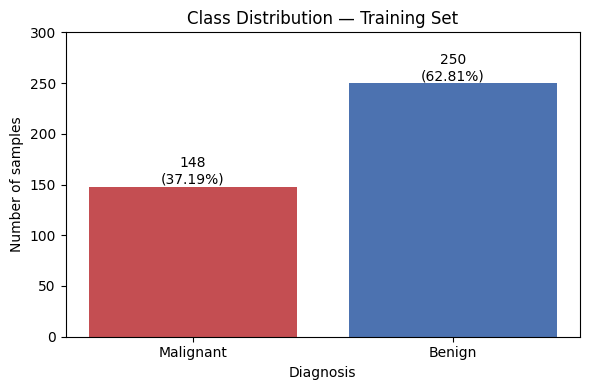

Majority class: Benign
Training accuracy from always predicting the majority class: 62.81%


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Count each class using the original label mapping.
class_counts = y_train.value_counts().reindex([0, 1], fill_value=0)

class_summary = pd.DataFrame({
    "Label": [0, 1],
    "Diagnosis": ["Malignant", "Benign"],
    "Samples": class_counts.to_numpy(),
    "Percentage (%)": (
        class_counts / len(y_train) * 100
    ).round(2).to_numpy()
})

display(class_summary)

# Plot the training-set class counts.
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    class_summary["Diagnosis"],
    class_summary["Samples"],
    color=["#C44E52", "#4C72B0"]
)

for bar, count, percentage in zip(
    bars,
    class_summary["Samples"],
    class_summary["Percentage (%)"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

ax.set_title("Class Distribution — Training Set")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, class_counts.max() * 1.20)

plt.tight_layout()
plt.show()

# Reference baseline calculated from training labels only.
majority_label = class_counts.idxmax()
majority_name = {0: "Malignant", 1: "Benign"}[majority_label]
baseline_accuracy = class_counts.max() / len(y_train)

print("Majority class:", majority_name)
print(
    "Training accuracy from always predicting the majority class:",
    f"{baseline_accuracy:.2%}"
)

#### Results and Interpretation — Training Class Distribution

Benign samples form the majority of the training set, representing
approximately **62.81%** of samples. Malignant samples account for
approximately **37.19%**.

A classifier that always predicts benign would achieve **62.81% training
accuracy**, but its malignant-class recall would be **0%**.

Therefore, accuracy alone is insufficient for evaluating our classifiers.
We should also examine malignant-class precision, recall, F1 score,
and the confusion matrix.

The class imbalance does not automatically require resampling.
We will first assess classifier performance using the existing distribution.

### 13. Training-Set EDA — Constant and Nearly Constant Features

A constant feature has the same value for every training sample and
cannot help distinguish samples within the training set.

We examine:
- The number of unique values in each feature.
- The percentage of samples sharing its most frequent value.

For this screening, we flag a non-constant feature as nearly constant
if one exact value occurs in at least 95% of training samples.
This is an exploratory threshold, not a universal rule.

This check detects repeated-value dominance. It does not detect every
case of very small numerical variation. No features are removed here.

In [13]:
import pandas as pd

# Count unique values in each training feature.
unique_counts = X_train.nunique()

# Percentage of samples containing the most frequent exact value.
most_common_pct = X_train.apply(
    lambda column: column.value_counts(normalize=True).max() * 100
)

# Identify constant and nearly constant features.
constant_mask = unique_counts == 1
nearly_constant_mask = (unique_counts > 1) & (most_common_pct >= 95)

variation_summary = pd.DataFrame({
    "Unique values": unique_counts,
    "Most common value (%)": most_common_pct.round(2),
    "Constant": constant_mask,
    "Nearly constant": nearly_constant_mask
})

display(
    variation_summary.sort_values(
        "Most common value (%)",
        ascending=False
    )
)

constant_features = X_train.columns[constant_mask].tolist()
nearly_constant_features = X_train.columns[nearly_constant_mask].tolist()

print("Number of constant features:", len(constant_features))
print("Constant features:", constant_features)

print("\nNumber of nearly constant features:", len(nearly_constant_features))
print("Nearly constant features:", nearly_constant_features)

print("\nNo features have been removed.")

,Unique values,Most common value (%),Constant,Nearly constant
mean concave points,381,2.51,False,False
mean concavity,380,2.51,False,False
worst concave points,356,2.51,False,False
worst concavity,382,2.51,False,False
concavity error,371,2.51,False,False
concave points error,368,2.51,False,False
perimeter error,376,1.01,False,False
mean symmetry,331,1.01,False,False
worst smoothness,311,1.01,False,False
worst radius,342,1.01,False,False


Number of constant features: 0
Constant features: []

Number of nearly constant features: 0
Nearly constant features: []

No features have been removed.


### Results and Interpretation — Constant and Nearly Constant Features

All 30 input features were examined using the 398 training samples.

- **Constant features: 0.** Every feature has more than one unique value.
- **Nearly constant features: 0.** No feature has one exact value occurring in at least 95% of training samples.
- The highest frequency of any single value within a feature was approximately **2.51%**, well below the screening threshold.

Therefore, no features are candidates for removal based on this repeated-value screening.

However, this check does not establish that every feature is useful for classification. A feature can vary while providing little predictive information. It also does not detect all cases of very small numerical variation.

so we will Retain all 30 features. No features were removed or modified.

### 14. Training-Set EDA — Descriptive Statistics and Feature Scales

We calculate summary statistics for all 30 training features:

- **Mean:** Average value.
- **Median:** Middle value when measurements are sorted.
- **Standard deviation:** Spread of measurements around the mean.
- **Minimum and maximum:** Smallest and largest observed values.
- **25th and 75th percentiles:** Boundaries of the middle 50% of values.
- **Range:** Maximum minus minimum.
- **Interquartile range (IQR):** 75th percentile minus 25th percentile.

These statistics help us understand typical measurements, variability,
and differences in numerical scale.

A larger range or standard deviation does not imply greater predictive
importance. Features may use different units or measurement scales.

We use X_train only. No scaling or other transformation is applied here.

In [14]:
# Summarize each training feature.
# Transposing makes each row represent one feature.
statistics = X_train.describe().T

# Calculate additional measures of spread.
statistics["range"] = statistics["max"] - statistics["min"]
statistics["IQR"] = statistics["75%"] - statistics["25%"]

# Display all feature statistics.
display(statistics.style.format(precision=6))

# Compare features with the largest and smallest numerical spreads.
print("\nFive features with the largest standard deviations:")
display(
    statistics[["mean", "std", "range"]]
    .nlargest(5, "std")
)

print("\nFive features with the smallest standard deviations:")
display(
    statistics[["mean", "std", "range"]]
    .nsmallest(5, "std")
)

,count,mean,std,min,25%,50%,75%,max,range,IQR
mean radius,398.000000,14.093847,3.489558,6.981000,11.662500,13.275000,15.772500,25.730000,18.749000,4.110000
mean texture,398.000000,19.341533,4.500457,9.710000,15.990000,18.825000,21.832500,39.280000,29.570000,5.842500
mean perimeter,398.000000,91.698945,24.063881,43.790000,74.902500,86.040000,103.675000,174.200000,130.410000,28.772500
mean area,398.000000,650.784171,340.295183,143.500000,417.100000,544.050000,777.400000,2010.000000,1866.500000,360.300000
mean smoothness,398.000000,0.095789,0.013349,0.062510,0.085902,0.095005,0.104750,0.142500,0.079990,0.018848
mean compactness,398.000000,0.103143,0.053362,0.019380,0.062760,0.088165,0.129775,0.345400,0.326020,0.067015
mean concavity,398.000000,0.088446,0.081509,0.000000,0.027920,0.058635,0.132375,0.426400,0.426400,0.104455
mean concave points,398.000000,0.048049,0.038697,0.000000,0.019675,0.032300,0.073910,0.191300,0.191300,0.054235
mean symmetry,398.000000,0.180493,0.028055,0.106000,0.161625,0.178050,0.195300,0.304000,0.198000,0.033675
mean fractal dimension,398.000000,0.062710,0.007314,0.049960,0.057480,0.061280,0.066110,0.097440,0.047480,0.008630



Five features with the largest standard deviations:


,mean,std,range
worst area,879.696734,565.421849,3246.800
mean area,650.784171,340.295183,1866.500
area error,38.215334,34.312051,216.872
worst perimeter,107.220678,33.774071,178.890
mean perimeter,91.698945,24.063881,130.410



Five features with the smallest standard deviations:


,mean,std,range
fractal dimension error,0.003806,0.002911,0.028945
smoothness error,0.006982,0.003034,0.028463
concave points error,0.011532,0.006354,0.052790
mean fractal dimension,0.062710,0.007314,0.047480
symmetry error,0.020682,0.008750,0.069411


#### Results and Interpretation — Descriptive Statistics

All 30 features contain **398 training observations**, consistent with
our training-set size.

**Differences in numerical scale**
Area and perimeter measurements have much larger numerical spreads than
features such as smoothness error and fractal dimension error.
For example:

- Worst area: standard deviation ≈ **565.42**
- Fractal dimension error: standard deviation ≈ **0.002911**

These differences reflect measurement scales and do not establish
predictive importance. Small standard deviations alone do not justify
removing features.

**Possible distribution asymmetry**
Some features have means noticeably above their medians:
- Mean area: mean ≈ **650.78**, median ≈ **544.05**
- Worst area: mean ≈ **879.70**, median ≈ **682.00**

These differences suggest possible right-skewed distributions, which
we will examine using histograms and skewness statistics.

**Implications for preprocessing**
If we select a scale-sensitive classifier, standardization may be useful.
Its parameters will be fitted on training data only and applied unchanged
to validation and test data.

No features are removed or transformed based on this summary.
Extreme values require further examination before being treated as errors.

### 15. Training-Set EDA — Feature Distributions and Skewness

We plot a histogram for each feature using training data only.

Each histogram shows:
- **Horizontal axis:** Feature values.
- **Vertical axis:** Number of training samples within each value interval.

We also calculate skewness:
- **Positive skewness:** A longer tail toward larger values.
- **Negative skewness:** A longer tail toward smaller values.
- **Skewness near zero:** Suggests approximate symmetry, but does not
  establish a normal distribution.

For descriptive screening, we use absolute skewness:
- Below 0.5: Low skewness.
- From 0.5 to below 1: Moderate skewness.
- 1 or above: High skewness.

These thresholds are exploratory guidelines. Skewness alone does not
justify transforming a feature or removing samples.

The histograms combine both diagnosis classes, so their shapes may
also reflect differences between malignant and benign samples.
No data are modified in this step.

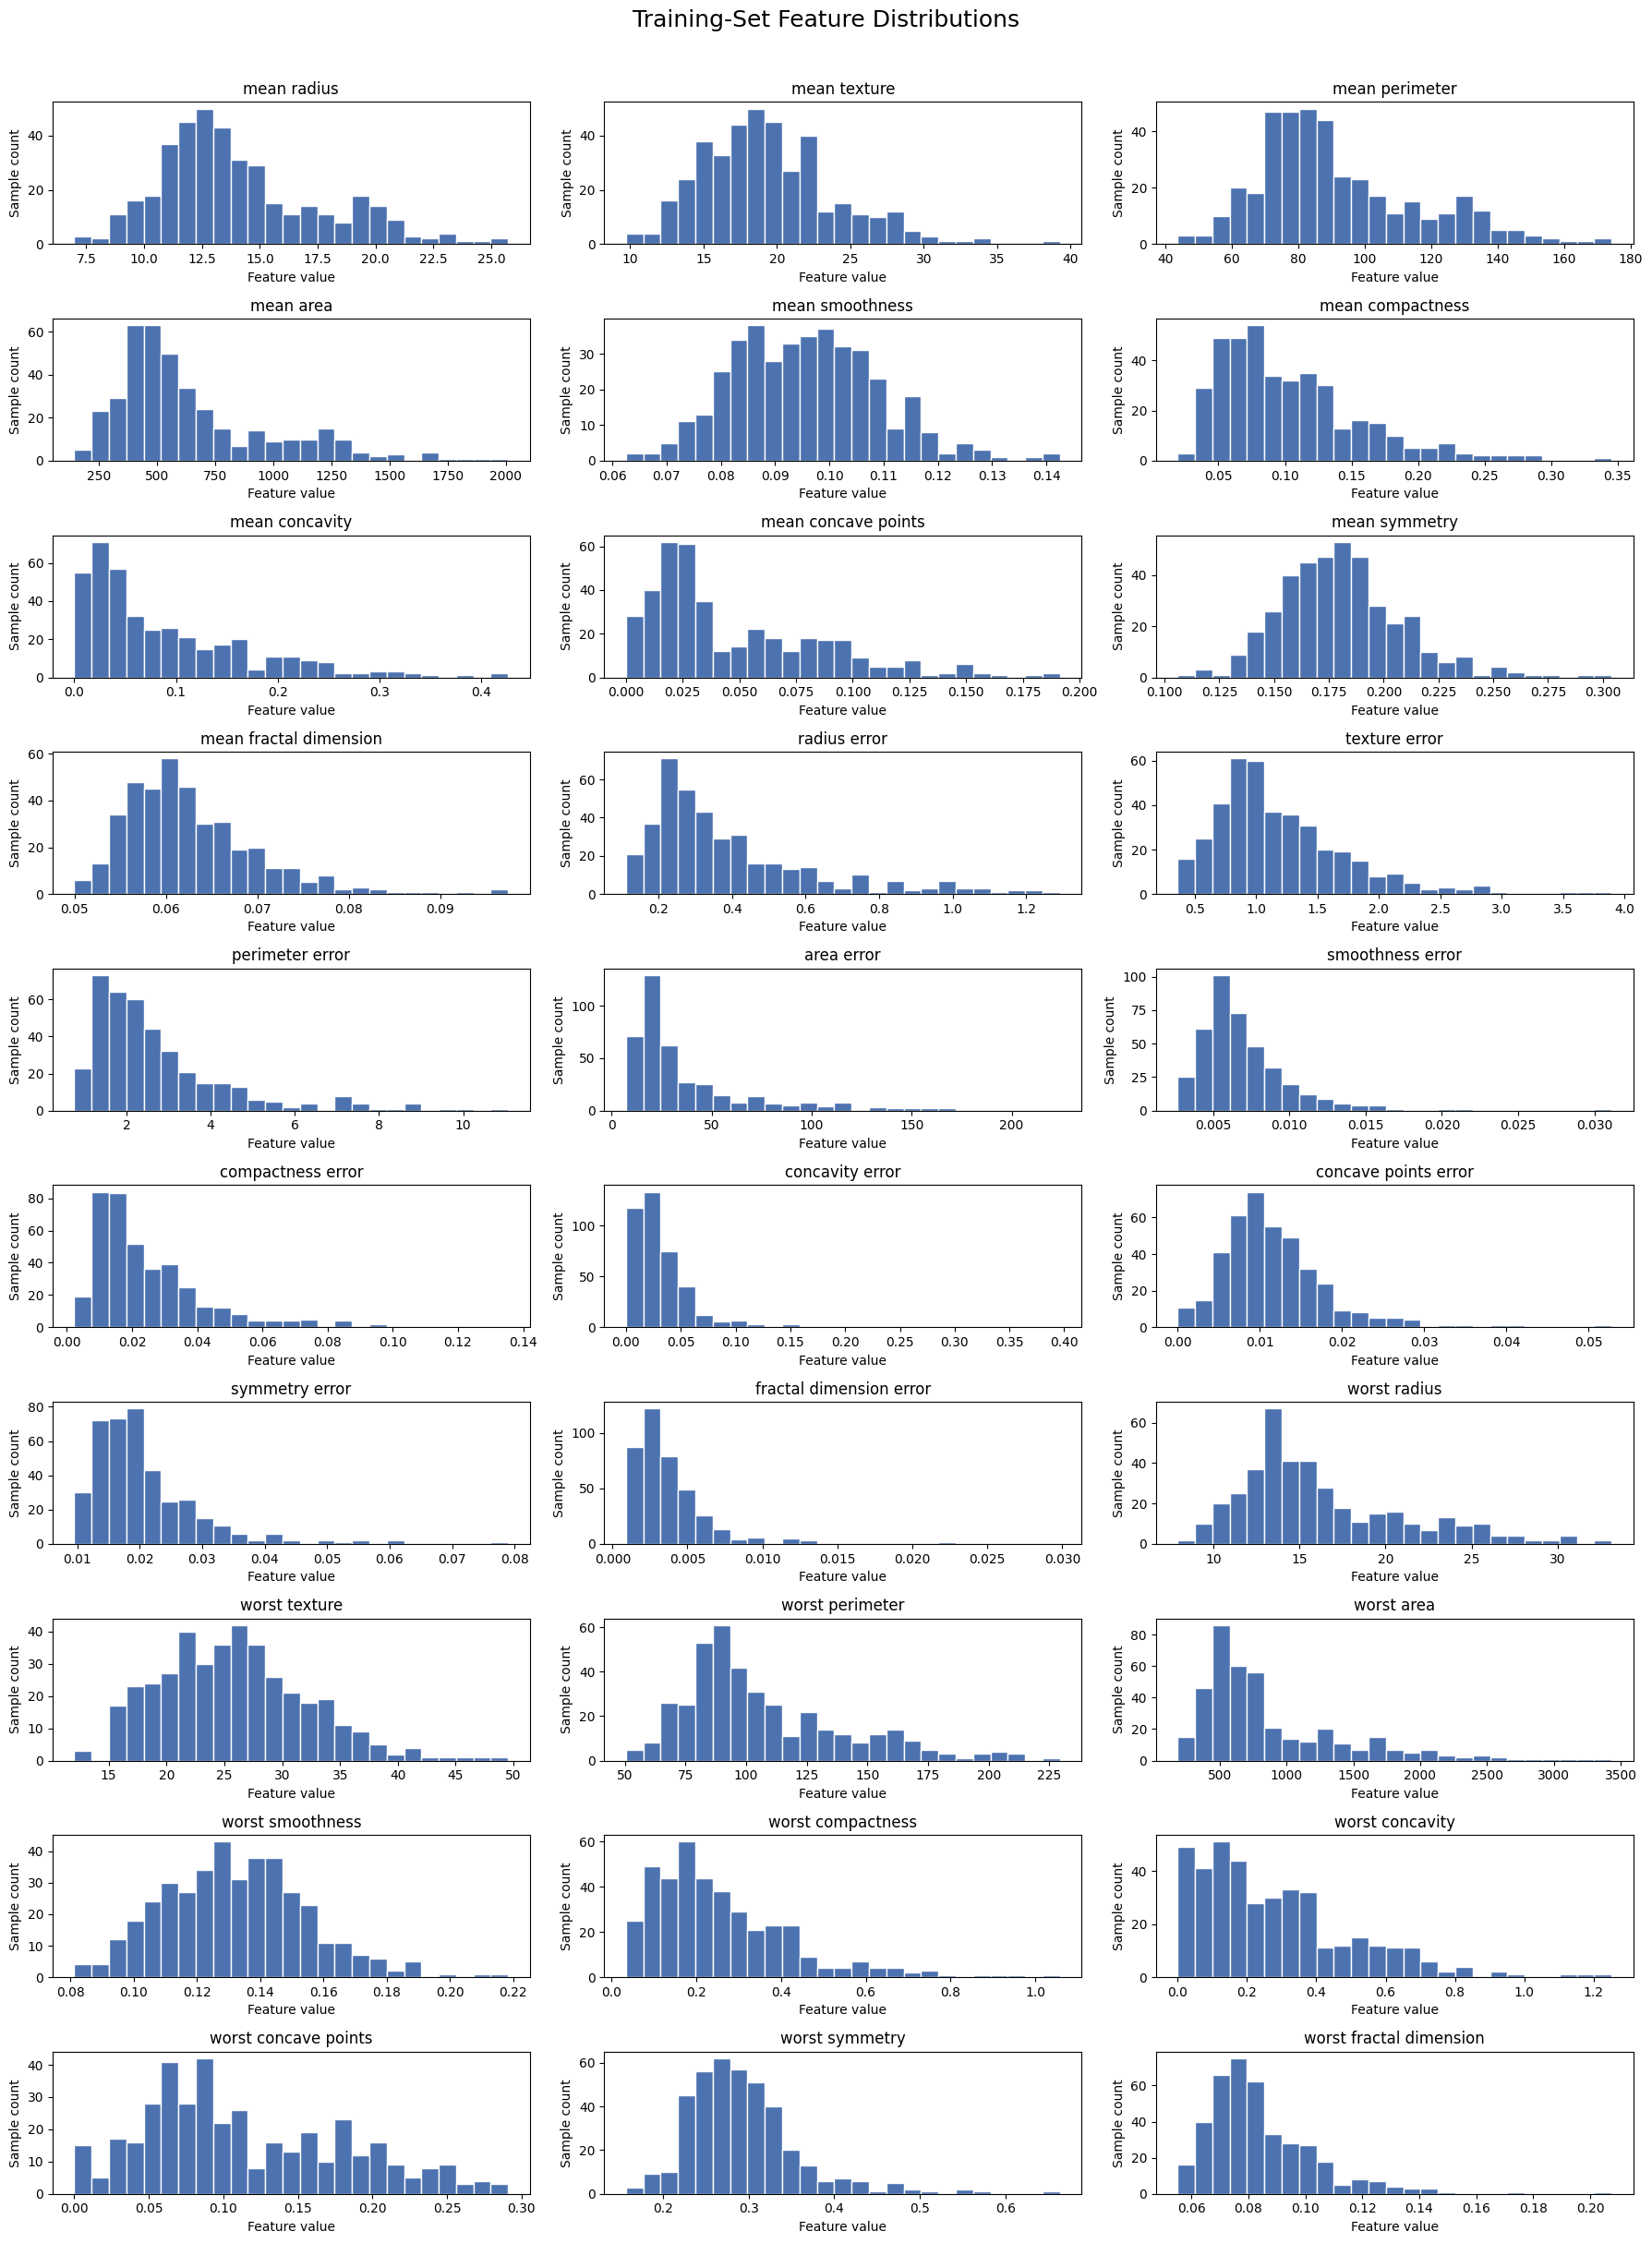

,Skewness,Absolute skewness,Category
concavity error,5.229,5.229,High
fractal dimension error,4.037,4.037,High
smoothness error,2.501,2.501,High
symmetry error,2.294,2.294,High
area error,2.242,2.242,High
compactness error,2.029,2.029,High
perimeter error,1.931,1.931,High
worst fractal dimension,1.772,1.772,High
worst area,1.707,1.707,High
concave points error,1.686,1.686,High



Number of features in each category:
Category
Low           2
Moderate      6
High         22
Undefined     0
Name: count, dtype: int64

No transformations or sample removals have been applied.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot all 30 training features with independent axis scales.
axes = X_train.hist(
    bins=25,
    figsize=(18, 24),
    layout=(10, 3),
    color="#4C72B0",
    edgecolor="white",
    grid=False
)

for ax in axes.ravel():
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Sample count")

plt.suptitle(
    "Training-Set Feature Distributions",
    fontsize=18,
    y=1.01
)
plt.tight_layout()
plt.show()

# Calculate sample skewness for each feature.
skewness = X_train.skew()
absolute_skewness = skewness.abs()

# Assign descriptive categories.
categories = np.select(
    [
        absolute_skewness < 0.5,
        absolute_skewness < 1,
        absolute_skewness >= 1
    ],
    ["Low", "Moderate", "High"],
    default="Undefined"
)

skewness_summary = pd.DataFrame({
    "Skewness": skewness,
    "Absolute skewness": absolute_skewness,
    "Category": categories
}).sort_values("Absolute skewness", ascending=False)

display(skewness_summary.round(3))

print("\nNumber of features in each category:")
print(
    skewness_summary["Category"]
    .value_counts()
    .reindex(["Low", "Moderate", "High", "Undefined"], fill_value=0)
)

print("\nNo transformations or sample removals have been applied.")

### Results and Interpretation — Feature Distributions and Skewness

Using training data only, the 30 features were categorized by absolute skewness:

- **Low skewness, below 0.5:** 2 features.
- **Moderate skewness, from 0.5 to below 1:** 6 features.
- **High skewness, 1 or above:** 22 features.
- **Undefined skewness:** 0 features.

All calculated skewness values were positive, indicating asymmetry toward larger values. The strongest skewness occurred in concavity error (5.229) and fractal dimension error (4.037).

Mean smoothness (0.376) and worst smoothness (0.403) had the lowest skewness. Low skewness suggests greater symmetry, but does not establish a normal distribution.

These results describe the combined training population. Differences between malignant and benign samples may contribute to the observed distribution shapes. High skewness alone does not establish that larger values are errors or that samples should be removed.



### 16. Training-Set EDA — Potential Outliers

We use the interquartile range (IQR) rule to identify unusually low
or high values within each training feature.

- Q1: 25th percentile.
- Q3: 75th percentile.
- IQR = Q3 − Q1.
- Lower boundary = Q1 − 1.5 × IQR.
- Upper boundary = Q3 + 1.5 × IQR.

Values outside these boundaries are flagged as potential outliers.

Boxplots show the median, middle 50% of measurements, and values beyond
the whiskers. Each feature uses its own numerical scale.

These flags are statistical screening results, not proof of data errors.
Skewed distributions and differences between diagnosis classes can
produce many flagged values. All samples are retained at this stage.

All boundaries are calculated using X_train only.

,Lower boundary,Upper boundary,Below boundary,Above boundary,Flagged values,Flagged (%)
area error,-23.3050,86.1950,0,40,40,10.05
radius error,-0.1242,0.8328,0,29,29,7.29
perimeter error,-0.8681,5.7689,0,27,27,6.78
worst area,-341.6250,1952.5750,0,25,25,6.28
compactness error,-0.0167,0.0613,0,23,23,5.78
smoothness error,0.0007,0.0125,0,22,22,5.53
symmetry error,0.0022,0.0363,0,20,20,5.03
mean area,-123.3500,1317.8500,0,20,20,5.03
concavity error,-0.0268,0.0827,0,19,19,4.77
fractal dimension error,-0.0015,0.0082,0,19,19,4.77


Total flagged feature values: 451
Training samples with at least one flag: 125 out of 398
Percentage of training samples with at least one flag: 31.41%


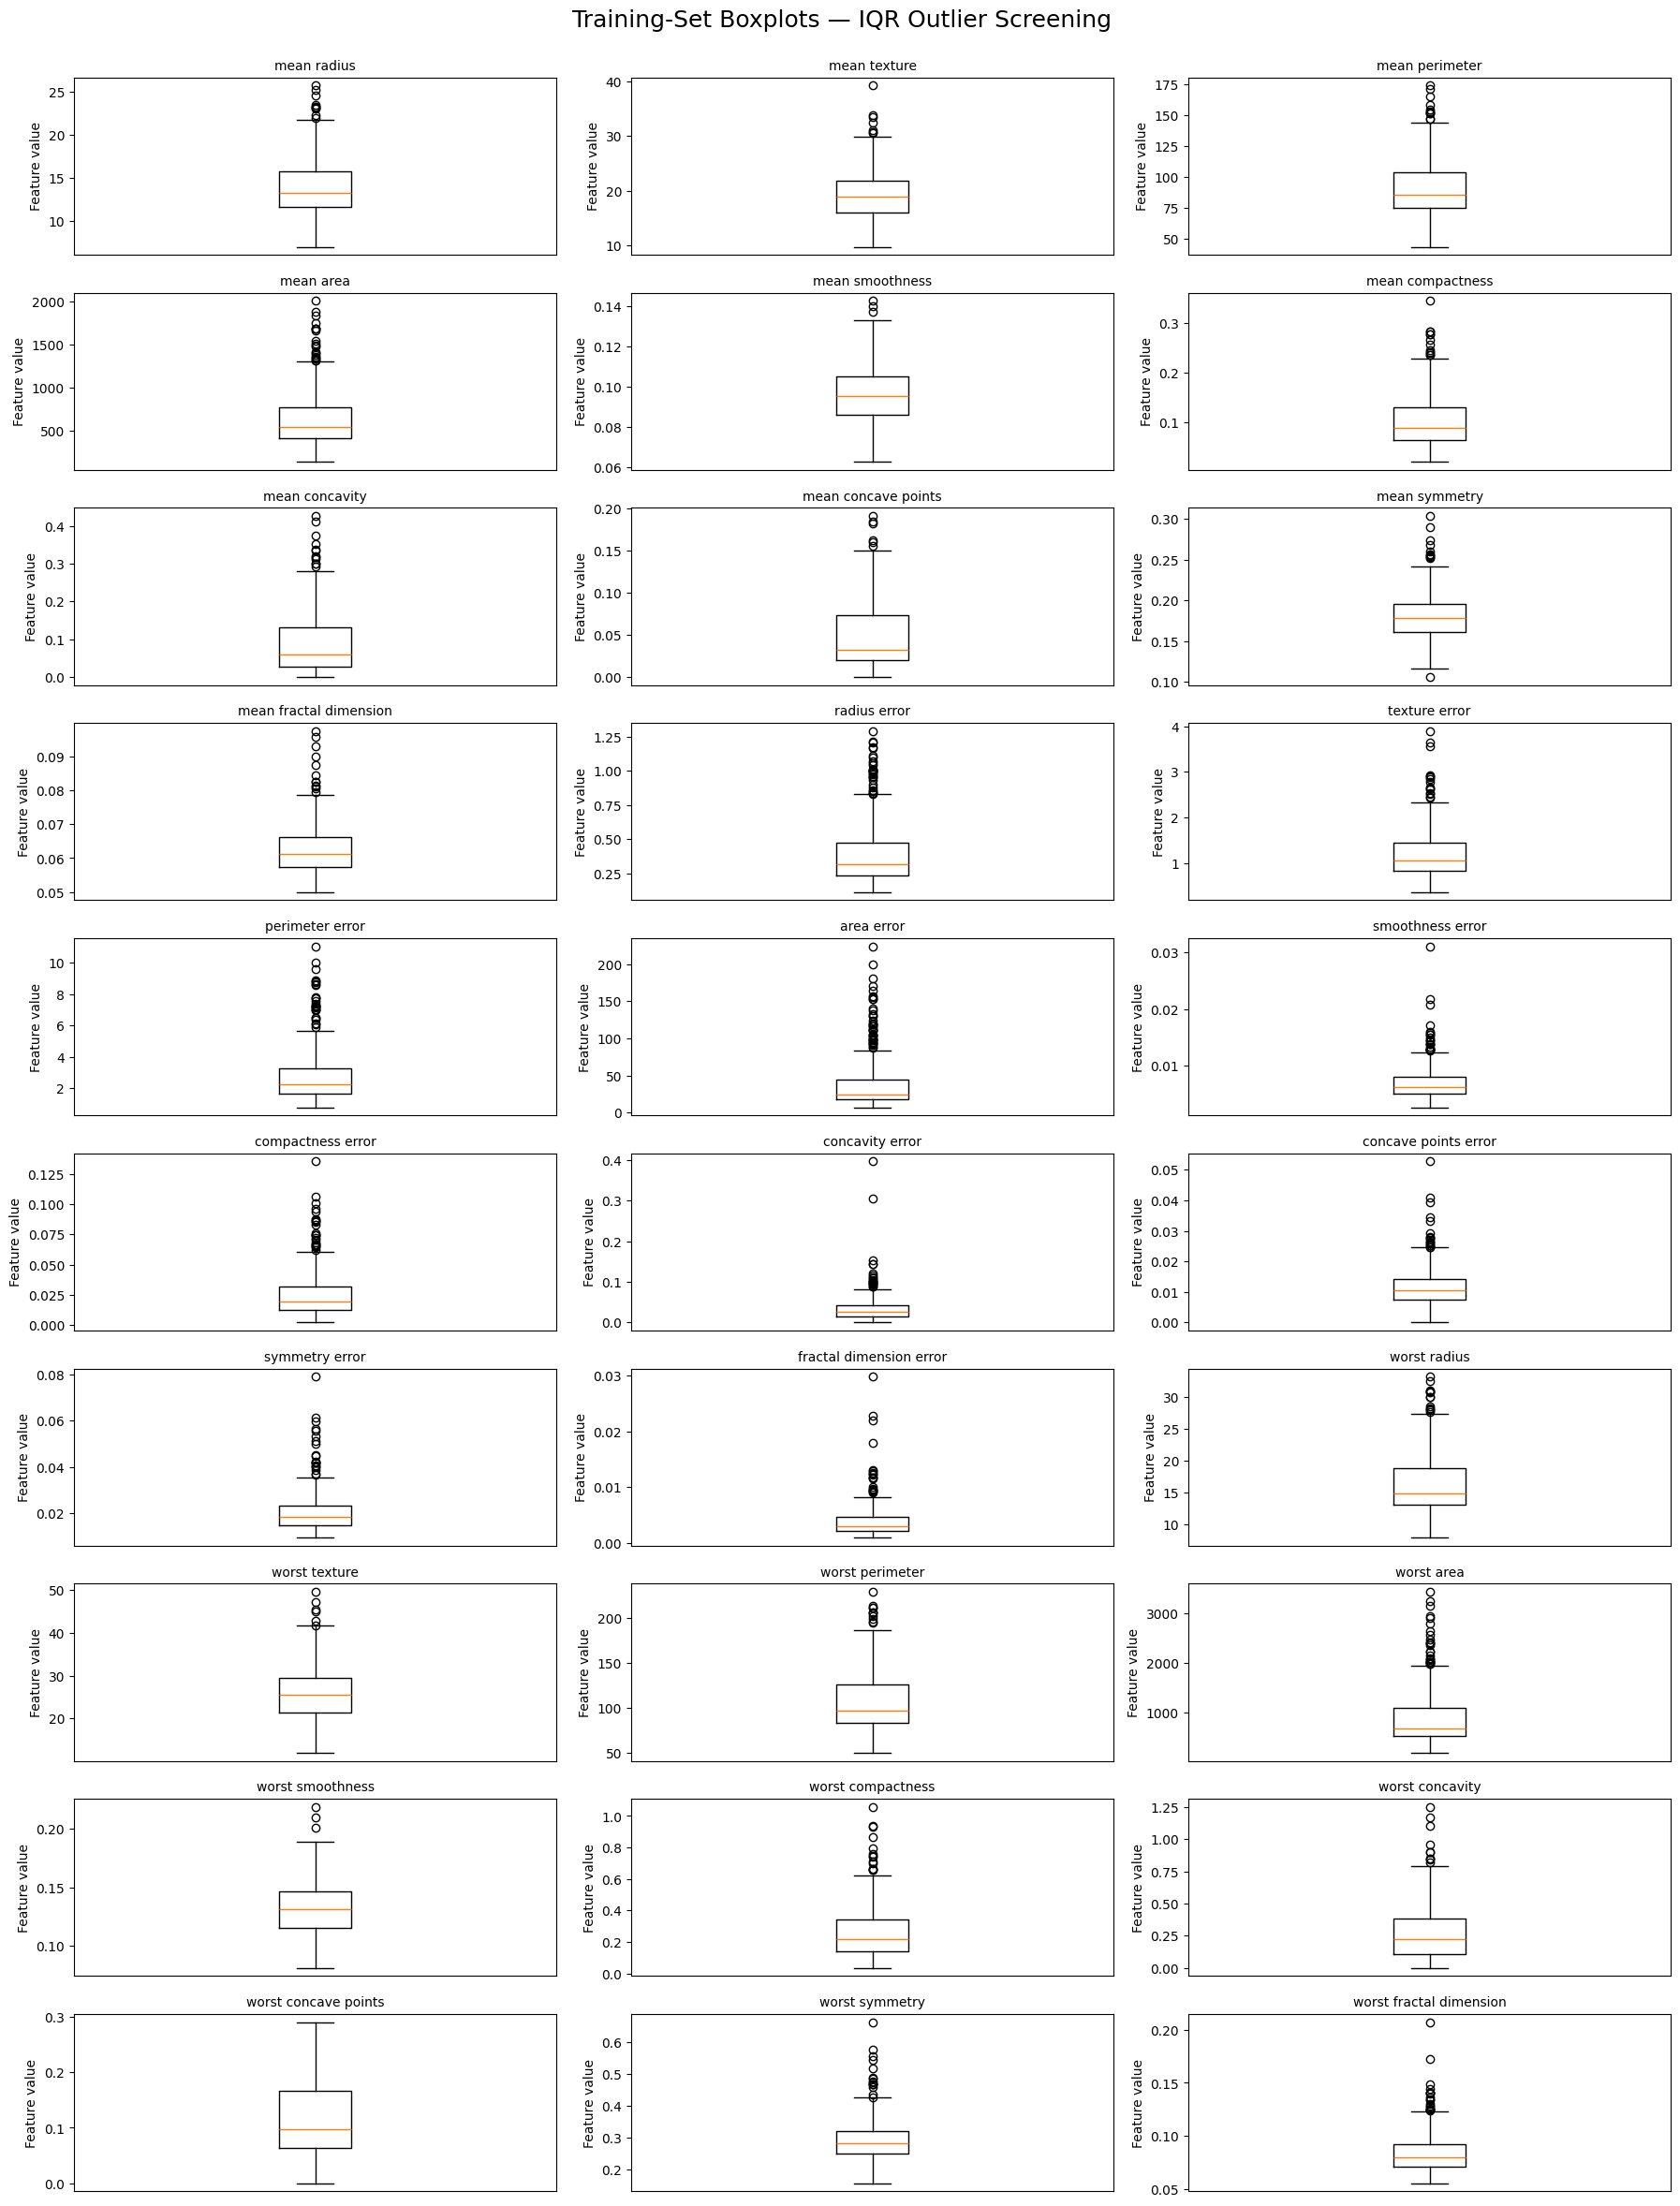


No samples or feature values have been removed or changed.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate training-set quartiles and IQR boundaries.
q1 = X_train.quantile(0.25)
q3 = X_train.quantile(0.75)
iqr = q3 - q1

lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

# Flag values outside each feature's boundaries.
below = X_train.lt(lower_bounds, axis="columns")
above = X_train.gt(upper_bounds, axis="columns")
outlier_mask = below | above

# Summarize flags per feature.
outlier_summary = pd.DataFrame({
    "Lower boundary": lower_bounds,
    "Upper boundary": upper_bounds,
    "Below boundary": below.sum(),
    "Above boundary": above.sum(),
    "Flagged values": outlier_mask.sum(),
    "Flagged (%)": (outlier_mask.mean() * 100).round(2)
}).sort_values("Flagged values", ascending=False)

display(outlier_summary.round(4))

# Count affected samples separately from individual flagged values.
flagged_samples = outlier_mask.any(axis=1)

print("Total flagged feature values:", int(outlier_mask.sum().sum()))
print(
    "Training samples with at least one flag:",
    int(flagged_samples.sum()),
    "out of",
    len(X_train)
)
print(
    "Percentage of training samples with at least one flag:",
    f"{flagged_samples.mean() * 100:.2f}%"
)

# Draw one boxplot per feature, using independent scales.
fig, axes = plt.subplots(10, 3, figsize=(18, 24))

for ax, feature in zip(axes.ravel(), X_train.columns):
    ax.boxplot(X_train[feature].dropna(), whis=1.5)
    ax.set_title(feature, fontsize=10)
    ax.set_ylabel("Feature value")
    ax.set_xticks([])

fig.suptitle("Training-Set Boxplots — IQR Outlier Screening", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("\nNo samples or feature values have been removed or changed.")

#### Results and Interpretation — Potential Outliers

The 1.5 × IQR rule flagged **451 individual feature values** across
**125 of 398 training samples (31.41%)**. A sample can contain flagged
values in multiple features.

The features with the most flagged values were:

| Feature | Flagged values | Percentage of training samples |
|---|---:|---:|
| Area error | 40 | 10.05% |
| Radius error | 29 | 7.29% |
| Perimeter error | 27 | 6.78% |
| Worst area | 25 | 6.28% |
| Compactness error | 23 | 5.78% |

Almost all flags were above the upper boundaries. Only one value,
in mean symmetry, was below its lower boundary.

Some calculated lower boundaries are negative. These are statistical
thresholds, not observed negative measurements.

These flags may reflect skewed distributions or differences between
diagnosis classes. Checking 30 features also increases the opportunity
for a sample to receive at least one flag.

We retain all training samples. The IQR rule alone does not justify
deleting or clipping measurements, and extreme values may contain
useful classification information.

### 17. Training-Set EDA — Feature Correlations

We calculate Pearson correlation between every pair of input features.

Correlation ranges from −1 to +1:
- **Near +1:** A strong positive linear relationship.
- **Near −1:** A strong negative linear relationship.
- **Near 0:** A weak linear relationship; nonlinear relationships may still exist.

A heatmap displays these relationships. We also list feature pairs with
absolute correlation of at least 0.90 as an exploratory screening threshold.

Strong correlation may indicate overlapping information, but it does not
prove that a feature is unnecessary or establish causation.

We exclude self-correlations and list each pair only once.
No features are removed, and the target labels are not included.

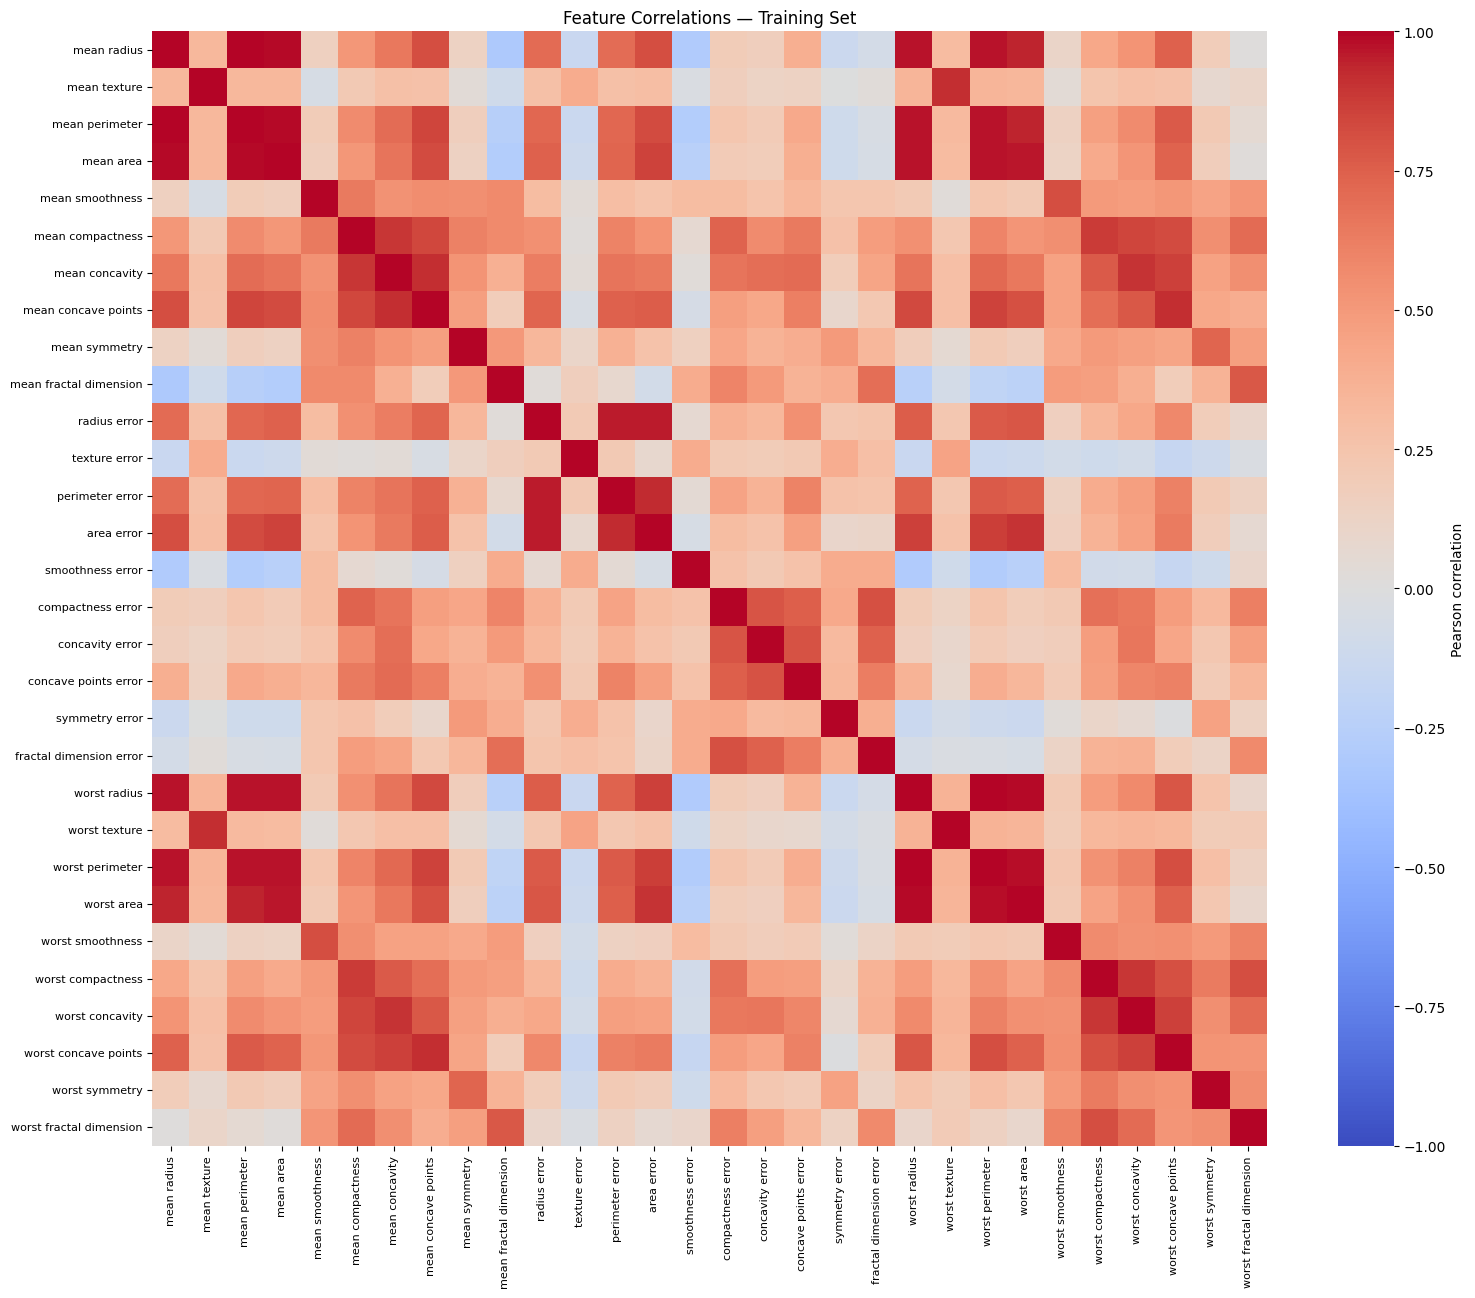

Number of unique pairs with |correlation| ≥ 0.90: 23


,Feature 1,Feature 2,Correlation,Absolute correlation
0,mean radius,mean perimeter,0.9978,0.9978
1,worst radius,worst perimeter,0.9934,0.9934
2,mean radius,mean area,0.9906,0.9906
3,mean perimeter,mean area,0.9895,0.9895
4,worst radius,worst area,0.9860,0.9860
5,worst perimeter,worst area,0.9785,0.9785
6,mean perimeter,worst perimeter,0.9749,0.9749
7,mean area,worst radius,0.9740,0.9740
8,mean radius,worst radius,0.9740,0.9740
9,mean perimeter,worst radius,0.9736,0.9736



No features have been removed.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Pearson correlations using training features only.
correlation_matrix = X_train.corr(method="pearson")

# Plot the full correlation matrix.
plt.figure(figsize=(16, 13))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=False,
    square=True,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Feature Correlations — Training Set")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Keep only the upper triangle, excluding self-correlations.
upper_triangle = np.triu(
    np.ones(correlation_matrix.shape, dtype=bool),
    k=1
)

# Convert unique feature pairs into a table.
correlation_pairs = (
    correlation_matrix.where(upper_triangle)
    .stack()
    .rename("Correlation")
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1", "Feature 2", "Correlation"
]

correlation_pairs["Absolute correlation"] = (
    correlation_pairs["Correlation"].abs()
)

# Flag strongly correlated pairs using the unrounded values.
strong_pairs = (
    correlation_pairs[
        correlation_pairs["Absolute correlation"] >= 0.90
    ]
    .sort_values("Absolute correlation", ascending=False)
    .reset_index(drop=True)
)

print("Number of unique pairs with |correlation| ≥ 0.90:", len(strong_pairs))
display(strong_pairs.round(4))

print("\nNo features have been removed.")

#### Results and Interpretation — Feature Correlations

We identified **23 unique feature pairs** with absolute Pearson
correlation of at least **0.90**. All 23 correlations were positive.

The strongest relationships included:

| Feature pair | Correlation |
|---|---:|
| Mean radius and mean perimeter | 0.9978 |
| Worst radius and worst perimeter | 0.9934 |
| Mean radius and mean area | 0.9906 |
| Mean perimeter and mean area | 0.9895 |
| Worst radius and worst area | 0.9860 |

These relationships are consistent with radius, perimeter, and area
describing related aspects of nucleus size. Several mean and worst
measurements also show strong relationships.

Strong feature correlations can make individual coefficients difficult
to interpret in linear models. However, correlated features may still
provide useful predictive information.

We retain all 30 features for the initial models. Regularization or
feature selection may be considered later and assessed using validation
performance.

Standardization does not remove these correlations. This analysis measures
relationships between features; it does not establish their importance
for predicting the diagnosis.

### 18. Training-Set EDA — Feature Distributions by Diagnosis

We compare feature distributions for malignant and benign samples using
training data only.

We calculate class-specific medians for all 30 features. Medians summarize
typical values while being less sensitive to extreme observations than means.

We also draw boxplots for six illustrative features:
- Mean radius
- Mean texture
- Mean area
- Mean smoothness
- Mean concavity
- Mean concave points

These features illustrate different measured characteristics; they are
not a ranking of predictive importance or a selected modeling subset.

The boxplots show differences in typical values, spread, and overlap.
Differences between classes may indicate useful classification information,
but they do not establish causation or guarantee accurate predictions.

All 30 features and all training samples are retained.

Feature medians by diagnosis — training set:


Diagnosis,Malignant,Benign
mean radius,17.360000,12.205000
mean texture,21.520000,17.305000
mean perimeter,114.300000,78.280000
mean area,938.600000,458.150000
mean smoothness,0.101550,0.089385
mean compactness,0.133200,0.073255
mean concavity,0.152500,0.034895
mean concave points,0.085670,0.022750
mean symmetry,0.188200,0.170600
mean fractal dimension,0.061275,0.061280


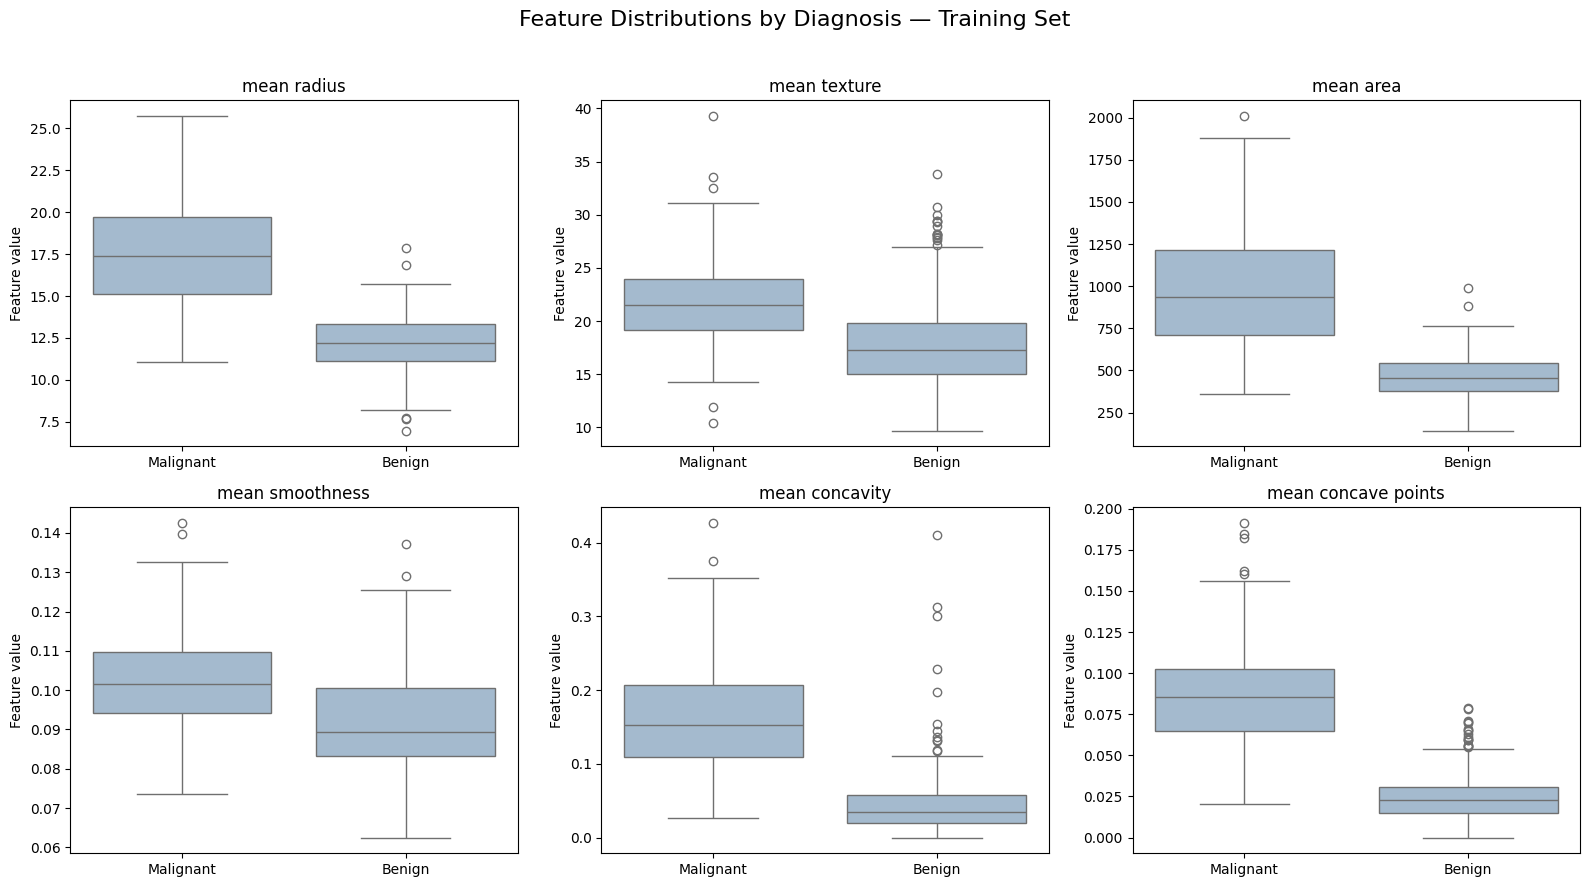


Medians for the six plotted features:


Diagnosis,Malignant,Benign
mean radius,17.36000,12.205000
mean texture,21.52000,17.305000
mean area,938.60000,458.150000
mean smoothness,0.10155,0.089385
mean concavity,0.15250,0.034895
mean concave points,0.08567,0.022750



X_train remains unchanged; diagnosis is only in the EDA table.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a separate table for training-set exploration.
eda_train = X_train.copy()
eda_train["Diagnosis"] = y_train.map({
    0: "Malignant",
    1: "Benign"
})

# Compare medians for all features.
class_medians = (
    eda_train.groupby("Diagnosis")[X_train.columns]
    .median()
    .T
    .reindex(columns=["Malignant", "Benign"])
)

print("Feature medians by diagnosis — training set:")
display(class_medians.round(6))

# Use a small illustrative group to keep the plots readable.
comparison_features = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness",
    "mean concavity",
    "mean concave points"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.ravel(), comparison_features):
    sns.boxplot(
        data=eda_train,
        x="Diagnosis",
        y=feature,
        order=["Malignant", "Benign"],
        color="#9DBAD5",
        ax=ax
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Feature value")

fig.suptitle(
    "Feature Distributions by Diagnosis — Training Set",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\nMedians for the six plotted features:")
display(class_medians.loc[comparison_features].round(6))

print("\nX_train remains unchanged; diagnosis is only in the EDA table.")

### Interpretation — Feature Differences Between Classes

The training-set medians show differences between malignant and benign samples:

- **Mean radius:** 17.360 for malignant samples versus 12.205 for benign samples.
- **Mean area:** 938.600 for malignant samples versus 458.150 for benign samples.
- **Mean concavity:** 0.152500 for malignant samples versus 0.034895 for benign samples.
- **Mean concave points:** 0.085670 for malignant samples versus 0.022750 for benign samples.

These observations suggest that measurements related to size and boundary
concavity may provide useful information for distinguishing the classes.

However, differences in medians do not establish complete class separation.
The boxplots help examine within-class variation and overlap. Predictive
usefulness must later be assessed through model evaluation.

Some features, such as mean fractal dimension, have almost identical class
medians. This alone does not establish that they are uninformative, because
their distributions or relationships with other features may still differ.

**Decision:** Retain all 30 features at this stage. No feature selection,
transformation, or sample removal is performed based on this comparison.
This analysis uses only the training set.

# Task 2 (Using Existing Libraries):





### 19. Classifier Selection and Justification

We select **Logistic Regression** and **Decision Tree** for breast cancer classification. Each classifier will be implemented using scikit-learn and independently from scratch, using the same dataset and training, validation, and test splits.

#### Logistic Regression

Logistic Regression provides a linear classification model that estimates the probability of a sample belonging to each diagnosis class.

Reasons for selection:

- **Suitable starting point:** Our training set contains 398 samples and 30 numerical features, making Logistic Regression a practical model to evaluate.
- **Regularization:** EDA identified 23 feature pairs with absolute correlation of at least 0.90. L2 regularization can help stabilize coefficient estimates and control model complexity without automatically removing correlated features.
- **Probability estimates:** The model supports probability-based evaluation and decision-threshold analysis.
- **Transparent implementation:** Its sigmoid function, loss, and gradient updates can be explained and implemented from scratch.

**Limitations:** A linear decision boundary may miss nonlinear patterns. Correlated features also make individual coefficients harder to interpret. We will standardize the features using training-set statistics and evaluate the model rather than assume linear separation.

#### Decision Tree

A Decision Tree predicts the diagnosis through a sequence of learned feature-threshold rules.

Reasons for selection:

- **Nonlinear relationships:** It can capture feature interactions and decision boundaries that Logistic Regression may not represent.
- **Interpretability:** A small tree can be visualized and explained through its decision rules.
- **Minimal preprocessing:** It does not require standardization or normally distributed features, making it compatible with the different scales and skewed distributions observed during EDA.
- **Transparent implementation:** Gini impurity, split selection, and recursive tree construction can be implemented from scratch.

**Limitations:** An unrestricted tree may overfit our relatively small training set. Its structure can also change with small changes in the data. We will use validation results to select appropriate limits on tree complexity.

#### Why Compare These Two Classifiers?

Both classifiers are permitted for the library and scratch tasks. Together, they provide a meaningful comparison between a linear probabilistic model and a nonlinear rule-based model.

The EDA motivates these choices but does not establish which classifier will perform better. We will use the validation set for model development and reserve the test set for final evaluation.

For each algorithm, the library and scratch versions will use matching preprocessing and comparable model settings to support a fair comparison.

### 20. Logistic Regression Using Scikit-learn

We implement Logistic Regression using scikit-learn with L2 regularization.

Our EDA identified substantial differences in feature scales. Therefore,
we use StandardScaler to subtract each feature's training mean and divide
by its training standard deviation.

A Pipeline combines standardization and Logistic Regression. Fitting the
pipeline on the training set ensures that both the scaling statistics and
model parameters are learned from training data only.

L2 regularization penalizes large weights and helps control model complexity.
We initially use C = 1.0, where smaller C values indicate stronger
regularization. This is a starting setting, not a value selected through
validation.

The model retains the original target encoding:
- 0 = malignant
- 1 = benign

Validation data will support model selection. Test data remain reserved for
final evaluation.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Combine training-only standardization with Logistic Regression.
lr_library = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=1.0,
        solver="lbfgs",       # Uses L2 regularization by default.
        max_iter=5000,
        tol=1e-6
    ))
])

# Pass the ORIGINAL, unscaled training DataFrame.
# The pipeline learns and applies scaling internally.
lr_library.fit(X_train, y_train)

# Inspect the fitted classifier.
fitted_lr = lr_library.named_steps["classifier"]

print("Library Logistic Regression fitted.")
print("Training samples:", X_train.shape[0])
print("Input features:", fitted_lr.n_features_in_)
print("Class order:", fitted_lr.classes_)
print("Solver iterations:", fitted_lr.n_iter_[0])
print("Maximum allowed iterations:", fitted_lr.max_iter)
print("Validation and test data were not used during fitting.")

Library Logistic Regression fitted.
Training samples: 398
Input features: 30
Class order: [0 1]
Solver iterations: 31
Maximum allowed iterations: 5000
Validation and test data were not used during fitting.


### 21. Library Logistic Regression — Validation Evaluation

We evaluate the fitted pipeline on the validation set. The pipeline applies
the scaling statistics learned from training data; it is not fitted again.

We treat malignant (original label 0) as the positive class:

- **Accuracy:** Proportion of all validation samples classified correctly.
- **Precision:** Among samples predicted as malignant, the proportion
  that are actually malignant.
- **Recall:** Among actual malignant samples, the proportion correctly
  identified as malignant.
- **F1 score:** Harmonic mean of malignant-class precision and recall.
- **ROC-AUC:** Measures how well predicted malignant probabilities rank
  malignant samples above benign samples across decision thresholds.
- **Confusion matrix:** Shows correct predictions and each type of error.

A false negative is a malignant sample predicted as benign.
A false positive is a benign sample predicted as malignant.

Class predictions use the model's default decision rule, corresponding
to a probability threshold of approximately 0.5. ROC-AUC uses probability
scores rather than predicted class labels.

These results support model development. The test set remains untouched.

,Metric,Validation score
0,Accuracy,0.9882
1,Precision — malignant,0.9697
2,Recall — malignant,1.0000
3,F1 — malignant,0.9846
4,ROC-AUC — malignant,1.0000


Validation samples: 85
True positives — malignant correctly identified: 32
False negatives — malignant predicted as benign: 0
False positives — benign predicted as malignant: 1
True negatives — benign correctly identified: 52


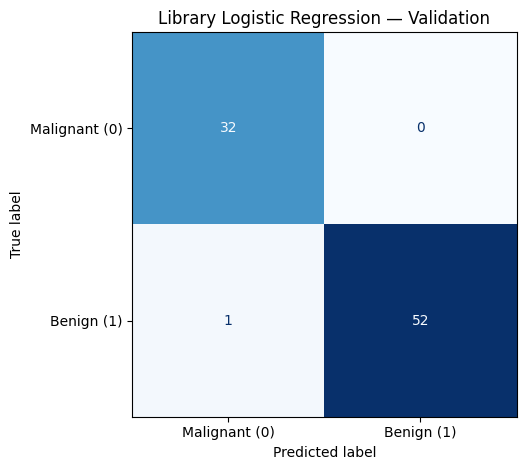

Test data have not been evaluated.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predict using the already-fitted pipeline. Do NOT call fit again.
y_val_pred_lr = lr_library.predict(X_val)
y_val_proba_lr = lr_library.predict_proba(X_val)

# Locate the probability column for malignant (original label 0).
class_order = lr_library.named_steps["classifier"].classes_
malignant_column = np.flatnonzero(class_order == 0).item()
p_val_malignant_lr = y_val_proba_lr[:, malignant_column]

# ROC-AUC expects the event of interest to be encoded as 1.
# This creates a temporary evaluation target; y_val remains unchanged.
y_val_malignant = (np.asarray(y_val) == 0).astype(int)

validation_metrics_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision — malignant",
        "Recall — malignant",
        "F1 — malignant",
        "ROC-AUC — malignant"
    ],
    "Validation score": [
        accuracy_score(y_val, y_val_pred_lr),
        precision_score(
            y_val, y_val_pred_lr, pos_label=0, zero_division=0
        ),
        recall_score(
            y_val, y_val_pred_lr, pos_label=0, zero_division=0
        ),
        f1_score(
            y_val, y_val_pred_lr, pos_label=0, zero_division=0
        ),
        roc_auc_score(y_val_malignant, p_val_malignant_lr)
    ]
})

display(validation_metrics_lr.round(4))

# Explicit order: malignant first, benign second.
# Rows = actual class; columns = predicted class.
cm_val_lr = confusion_matrix(
    y_val, y_val_pred_lr, labels=[0, 1]
)

# With malignant first, the layout is [[TP, FN], [FP, TN]].
tp, fn, fp, tn = cm_val_lr.ravel()

print("Validation samples:", len(y_val))
print("True positives — malignant correctly identified:", tp)
print("False negatives — malignant predicted as benign:", fn)
print("False positives — benign predicted as malignant:", fp)
print("True negatives — benign correctly identified:", tn)

ConfusionMatrixDisplay(
    confusion_matrix=cm_val_lr,
    display_labels=["Malignant (0)", "Benign (1)"]
).plot(cmap="Blues", values_format="d", colorbar=False)

plt.title("Library Logistic Regression — Validation")
plt.tight_layout()
plt.show()

print("Test data have not been evaluated.")

### 22. Logistic Regression — Regularization Tuning

We compare C values of 0.001, 0.01, 0.1, 1, 10, and 100 while keeping
L2 regularization, the solver, and the default decision threshold fixed.

Each candidate pipeline learns its scaling statistics and model parameters
using training data only. We then evaluate its predictions on the same
validation set.

Before comparing candidates, we define the selection rule:

1. Select the highest malignant-class F1 score.
2. If F1 scores tie, prefer higher malignant recall.
3. If both scores tie, prefer the smaller C (stronger regularization).

F1 is the primary criterion because it considers both precision and recall.
Recall is also reported separately to make missed malignant samples visible.
This is an assignment-level selection rule, not a clinically validated
decision policy.

Validation results are used for model selection and may therefore be
optimistic. The test set remains untouched for final evaluation.

In [21]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

C_candidates = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

lr_candidates = {}
tuning_rows = []

# Temporary target for malignant-class ROC-AUC.
y_val_malignant = (np.asarray(y_val) == 0).astype(int)

for C_value in C_candidates:
    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            C=C_value,
            solver="lbfgs",
            max_iter=5000,
            tol=1e-6
        ))
    ])

    # Fit only on training data.
    candidate.fit(X_train, y_train)

    train_predictions = candidate.predict(X_train)
    val_predictions = candidate.predict(X_val)

    classes = candidate.named_steps["classifier"].classes_
    malignant_column = np.flatnonzero(classes == 0).item()
    val_malignant_probability = (
        candidate.predict_proba(X_val)[:, malignant_column]
    )

    lr_candidates[C_value] = candidate

    tuning_rows.append({
        "C": C_value,
        "Training F1": f1_score(
            y_train, train_predictions, pos_label=0, zero_division=0
        ),
        "Validation accuracy": accuracy_score(y_val, val_predictions),
        "Validation precision": precision_score(
            y_val, val_predictions, pos_label=0, zero_division=0
        ),
        "Validation recall": recall_score(
            y_val, val_predictions, pos_label=0, zero_division=0
        ),
        "Validation F1": f1_score(
            y_val, val_predictions, pos_label=0, zero_division=0
        ),
        "Validation ROC-AUC": roc_auc_score(
            y_val_malignant, val_malignant_probability
        )
    })

# Rank using full-precision scores; round only for display.
lr_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=["Validation F1", "Validation recall", "C"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(lr_tuning_results.round(4))

best_C = float(lr_tuning_results.loc[0, "C"])
lr_library_final = lr_candidates[best_C]

print("Selected C:", best_C)
print("Selected model stored as: lr_library_final")
print("The original lr_library model is preserved.")
print("Test data have not been used.")

,C,Training F1,Validation accuracy,Validation precision,Validation recall,Validation F1,Validation ROC-AUC
0,0.100,0.9795,0.9882,0.9697,1.0000,0.9846,0.9988
1,1.000,0.9829,0.9882,0.9697,1.0000,0.9846,1.0000
2,10.000,0.9864,0.9882,1.0000,0.9688,0.9841,0.9994
3,100.000,0.9966,0.9647,0.9394,0.9688,0.9538,0.9941
4,0.010,0.9391,0.9647,1.0000,0.9062,0.9508,0.9982
5,0.001,0.8254,0.9059,1.0000,0.7500,0.8571,0.9976


Selected C: 0.1
Selected model stored as: lr_library_final
The original lr_library model is preserved.
Test data have not been used.


### Results and Interpretation — Logistic Regression Tuning

Six regularization strengths were compared using the same training and
validation splits.

C = 0.1 and C = 1.0 achieved identical validation F1 scores (0.9846),
malignant recall (1.0000), precision (0.9697), and accuracy (0.9882).

Following the predefined selection rule, C = 0.1 was selected because
it provides stronger regularization among candidates tied on F1 and recall.
Its ROC-AUC was 0.9988, compared with 1.0000 for C = 1.0. Therefore,
the selected model was not superior on every metric.

At C = 100, training F1 increased to 0.9966 while validation F1 fell to
0.9538, suggesting increased overfitting. At the smallest C values,
lower training and validation F1 scores suggest underfitting.

The selected pipeline is stored as lr_library_final. It remains fitted
on the 398 training samples, with C = 0.1 and the default classification
threshold.

These validation results were used for model selection and are not an
independent final performance estimate. The test set has not been used.

### 23. Library Logistic Regression — Final Test Evaluation

After validation-based tuning, we selected C = 0.1 and retained the default
classification threshold.

We now evaluate the selected pipeline on the previously unused test set.
The model and scaler remain fitted on the 398 training samples. No fitting
is performed on validation or test data.

Malignant (original label 0) is treated as the positive class. We report
accuracy, malignant-class precision, recall, F1, ROC-AUC, and a confusion
matrix.

These test results provide the final held-out evaluation of this fitted
model. They will not be used to change its hyperparameters, preprocessing,
or decision threshold.

Selected C: 0.1
Test samples: 86


,Metric,Test score
0,Accuracy,0.9767
1,Precision — malignant,1.0000
2,Recall — malignant,0.9375
3,F1 — malignant,0.9677
4,ROC-AUC — malignant,0.9936


True positives — malignant correctly identified: 30
False negatives — malignant predicted as benign: 2
False positives — benign predicted as malignant: 0
True negatives — benign correctly identified: 54


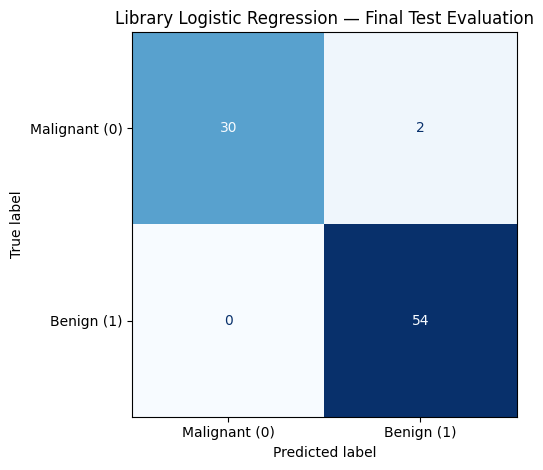

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Use the selected, already-fitted pipeline. Do not call fit again.
y_test_pred_lr = lr_library_final.predict(X_test)
y_test_proba_lr = lr_library_final.predict_proba(X_test)

# Locate the malignant probability column explicitly.
final_lr_classifier = lr_library_final.named_steps["classifier"]
malignant_column = np.flatnonzero(
    final_lr_classifier.classes_ == 0
).item()

p_test_malignant_lr = y_test_proba_lr[:, malignant_column]

# Temporary binary target for malignant-class ROC-AUC.
# The original y_test remains unchanged.
y_test_malignant = (np.asarray(y_test) == 0).astype(int)

test_metrics_lr = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision — malignant",
        "Recall — malignant",
        "F1 — malignant",
        "ROC-AUC — malignant"
    ],
    "Test score": [
        accuracy_score(y_test, y_test_pred_lr),
        precision_score(
            y_test, y_test_pred_lr, pos_label=0, zero_division=0
        ),
        recall_score(
            y_test, y_test_pred_lr, pos_label=0, zero_division=0
        ),
        f1_score(
            y_test, y_test_pred_lr, pos_label=0, zero_division=0
        ),
        roc_auc_score(y_test_malignant, p_test_malignant_lr)
    ]
})

print("Selected C:", final_lr_classifier.C)
print("Test samples:", len(y_test))
display(test_metrics_lr.round(4))

# Rows = actual class; columns = predicted class.
# Ordering malignant first gives [[TP, FN], [FP, TN]].
cm_test_lr = confusion_matrix(
    y_test, y_test_pred_lr, labels=[0, 1]
)
tp_test_lr, fn_test_lr, fp_test_lr, tn_test_lr = cm_test_lr.ravel()

print("True positives — malignant correctly identified:", tp_test_lr)
print("False negatives — malignant predicted as benign:", fn_test_lr)
print("False positives — benign predicted as malignant:", fp_test_lr)
print("True negatives — benign correctly identified:", tn_test_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test_lr,
    display_labels=["Malignant (0)", "Benign (1)"]
).plot(cmap="Blues", values_format="d", colorbar=False)

plt.title("Library Logistic Regression — Final Test Evaluation")
plt.tight_layout()
plt.show()

### Results and Interpretation — Logistic Regression Final Test Evaluation

The selected Logistic Regression pipeline, with C = 0.1, was evaluated
on 86 test samples: 32 malignant and 54 benign. The model and scaler
remained fitted on the 398 training samples.

Malignant (label 0) was treated as the positive class.

#### Confusion Matrix Results

- **True positives: 30** — malignant samples correctly identified.
- **False negatives: 2** — malignant samples incorrectly predicted as benign.
- **False positives: 0** — no benign samples predicted as malignant.
- **True negatives: 54** — benign samples correctly identified.

#### Evaluation Results

| Metric | Calculation | Test result |
|---|---|---:|
| Accuracy | (30 + 54) / 86 | 97.67% |
| Malignant precision | 30 / (30 + 0) | 100% |
| Malignant recall | 30 / (30 + 2) | 93.75% |
| Malignant F1 | 60 / (60 + 0 + 2) | 96.77% |
| Malignant ROC-AUC | Calculated from malignant probability scores | 0.9936 |

#### Interpretation

The model correctly classified 84 of 86 test samples. All malignant
predictions were correct, giving 100% precision. However, two malignant
samples were missed, reducing recall to 93.75%.

The high ROC-AUC indicates strong ranking performance, but does not
eliminate classification errors at the chosen threshold.

For the selected model, validation F1 was 98.46% and test F1 was 96.77%.
This difference reflects performance on different samples; it does not
by itself establish overfitting.

These results describe one held-out test split and do not guarantee
equivalent performance on future data. No model settings will be changed
based on these test results.

### 24. Decision Tree Using Scikit-learn

We train a Decision Tree classifier that predicts the diagnosis through
a sequence of feature-threshold rules.

The tree uses Gini impurity to measure class mixing. At each node,
it searches for a split that reduces the weighted impurity of the
resulting child nodes.

We use the original feature values because Decision Trees do not require
standardization.

Our initial settings are:

- **criterion="gini":** Use Gini impurity to evaluate splits.
- **max_depth=3:** Limit the tree to three levels of splits.
- **min_samples_leaf=5:** Require at least five training samples per leaf.
- **random_state=42:** Support reproducible fitting.

Depth and leaf-size limits restrict model complexity and may reduce
overfitting. However, overly restrictive limits can cause underfitting.
These are initial settings; validation results will guide later tuning.

We fit the model using training data only.

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Create an initial Decision Tree with controlled complexity.
dt_library = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

# Fit using the original, unscaled training features.
dt_library.fit(X_train, y_train)

print("Library Decision Tree fitted.")
print("Training samples:", X_train.shape[0])
print("Input features:", dt_library.n_features_in_)
print("Class order:", dt_library.classes_)
print("Actual tree depth:", dt_library.get_depth())
print("Number of leaves:", dt_library.get_n_leaves())
print("Total nodes:", dt_library.tree_.node_count)


Library Decision Tree fitted.
Training samples: 398
Input features: 30
Class order: [0 1]
Actual tree depth: 3
Number of leaves: 7
Total nodes: 13


### Results and Interpretation — Decision Tree Training

The Decision Tree was fitted using 398 training samples and all 30
original, unscaled features.

The fitted tree has:
- **Maximum depth: 3**, matching the configured depth limit.
- **Leaf nodes: 7**, representing the final prediction groups.
- **Internal decision nodes: 6**, containing feature-threshold rules.
- **Total nodes: 13**.

Each leaf contains at least five training samples, as required by
min_samples_leaf=5. A leaf is not necessarily pure: it may contain
both malignant and benign samples.

The class order is [0, 1], corresponding to malignant and benign.

These results describe the fitted tree's structure. They do not establish
predictive performance or whether the tree is underfitting or overfitting.
Validation evaluation is the next step.

### 25. Library Decision Tree — Validation Evaluation

We evaluate the fitted Decision Tree using the original, unscaled
validation features. The model is not fitted again.

For consistency with Logistic Regression, we report accuracy,
malignant-class precision, recall, F1, ROC-AUC, and a confusion matrix.

Malignant (label 0) is the positive class:
- A false negative is a malignant sample predicted as benign.
- A false positive is a benign sample predicted as malignant.

ROC-AUC uses estimated malignant probabilities, calculated from the
class proportions in the training samples within each reached leaf.
Other metrics use predicted class labels.

This evaluation assesses the initial tree settings: max_depth=3 and
min_samples_leaf=5. Test data are not used in this step.

,Metric,Validation score
0,Accuracy,0.9765
1,Precision — malignant,0.9412
2,Recall — malignant,1.0000
3,F1 — malignant,0.9697
4,ROC-AUC — malignant,0.9885


Validation samples: 85
True positives — malignant correctly identified: 32
False negatives — malignant predicted as benign: 0
False positives — benign predicted as malignant: 2
True negatives — benign correctly identified: 51


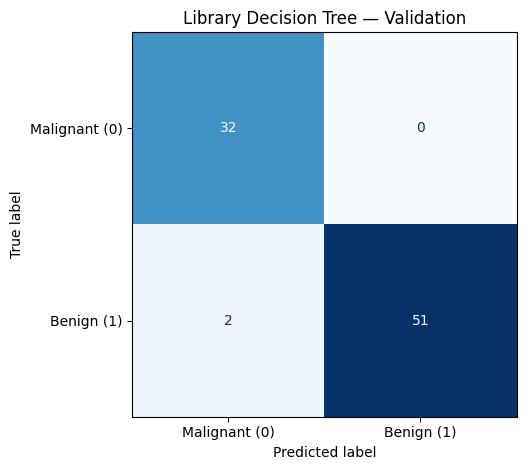

Test data were not used in this evaluation.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predict with the fitted tree using unscaled validation features.
y_val_pred_dt = dt_library.predict(X_val)
y_val_proba_dt = dt_library.predict_proba(X_val)

# Locate the malignant probability column.
malignant_column_dt = np.flatnonzero(
    dt_library.classes_ == 0
).item()

p_val_malignant_dt = y_val_proba_dt[:, malignant_column_dt]

# Temporary target for malignant-class ROC-AUC.
y_val_malignant = (np.asarray(y_val) == 0).astype(int)

validation_metrics_dt = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision — malignant",
        "Recall — malignant",
        "F1 — malignant",
        "ROC-AUC — malignant"
    ],
    "Validation score": [
        accuracy_score(y_val, y_val_pred_dt),
        precision_score(
            y_val, y_val_pred_dt, pos_label=0, zero_division=0
        ),
        recall_score(
            y_val, y_val_pred_dt, pos_label=0, zero_division=0
        ),
        f1_score(
            y_val, y_val_pred_dt, pos_label=0, zero_division=0
        ),
        roc_auc_score(y_val_malignant, p_val_malignant_dt)
    ]
})

display(validation_metrics_dt.round(4))

# Rows = actual; columns = predicted.
# Malignant-first ordering gives [[TP, FN], [FP, TN]].
cm_val_dt = confusion_matrix(
    y_val, y_val_pred_dt, labels=[0, 1]
)
tp_val_dt, fn_val_dt, fp_val_dt, tn_val_dt = cm_val_dt.ravel()

print("Validation samples:", len(y_val))
print("True positives — malignant correctly identified:", tp_val_dt)
print("False negatives — malignant predicted as benign:", fn_val_dt)
print("False positives — benign predicted as malignant:", fp_val_dt)
print("True negatives — benign correctly identified:", tn_val_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_val_dt,
    display_labels=["Malignant (0)", "Benign (1)"]
).plot(cmap="Blues", values_format="d", colorbar=False)

plt.title("Library Decision Tree — Validation")
plt.tight_layout()
plt.show()

print("Test data were not used in this evaluation.")

### Results and Interpretation — Decision Tree Validation

The initial Decision Tree, with max_depth=3 and min_samples_leaf=5,
was evaluated on 85 validation samples. Malignant (label 0) was treated
as the positive class.

#### Confusion Matrix Results

- **True positives: 32** — malignant samples correctly identified.
- **False negatives: 0** — no malignant samples predicted as benign.
- **False positives: 2** — benign samples incorrectly predicted as malignant.
- **True negatives: 51** — benign samples correctly identified.

#### Metric Calculations

| Metric | Calculation | Validation result |
|---|---|---:|
| Accuracy | (32 + 51) / 85 | 97.65% |
| Malignant precision | 32 / (32 + 2) | 94.12% |
| Malignant recall | 32 / (32 + 0) | 100% |
| Malignant F1 | 64 / (64 + 2 + 0) | 96.97% |
| Malignant ROC-AUC | Calculated from malignant probability scores | 0.9885 |

#### Interpretation

The tree correctly classified 83 of 85 validation samples and detected
every malignant sample in this split. Its two errors were false positives.

Compared with the selected Logistic Regression model (C = 0.1), the
initial tree achieved the same malignant recall but produced one
additional false positive. Its validation precision, F1, accuracy,
and ROC-AUC were consequently lower.

This comparison does not establish that Logistic Regression will always
perform better. The validation set is small, and the Decision Tree's
settings have not yet been tuned.

We will next compare a predefined set of tree settings using training
and validation data only. Test results will not guide this selection.

### 26. Decision Tree — Hyperparameter Tuning and Visualization

We perform a small grid search over:

- Maximum depth: 2, 3, 4, 5, and 6.
- Minimum samples per leaf: 1, 5, 10, and 20.

This produces 20 candidate trees. Each candidate is fitted on the same
training set and evaluated on the same validation set. Gini impurity
and random_state=42 remain fixed.

We define the selection rule before running the search:

1. Highest validation malignant-class F1.
2. If tied, highest validation malignant recall.
3. If still tied, smaller maximum depth.
4. If still tied, larger minimum samples per leaf.

The final tie-breaks favor more restrictive complexity settings.

A heatmap compares validation F1 across all combinations. A second plot
compares training and validation F1 across depths while holding the
minimum leaf size at its selected value.

Training scores are diagnostic only and do not determine the winner.
The selected combination is the best under this rule among the candidates
tested; it is not necessarily optimal among all possible settings.

Test data and previously observed test results are not used in this search.

In [25]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, recall_score

depth_candidates = [2, 3, 4, 5, 6]
leaf_candidates = [1, 5, 10, 20]

dt_candidates = {}
dt_tuning_rows = []

for depth in depth_candidates:
    for leaf_size in leaf_candidates:
        candidate = DecisionTreeClassifier(
            criterion="gini",
            max_depth=depth,
            min_samples_leaf=leaf_size,
            random_state=42
        )

        # Fit using original, unscaled training data only.
        candidate.fit(X_train, y_train)

        train_predictions = candidate.predict(X_train)
        val_predictions = candidate.predict(X_val)

        dt_candidates[(depth, leaf_size)] = candidate

        dt_tuning_rows.append({
            "Max depth": depth,
            "Min samples leaf": leaf_size,
            "Training F1": f1_score(
                y_train, train_predictions,
                pos_label=0, zero_division=0
            ),
            "Validation F1": f1_score(
                y_val, val_predictions,
                pos_label=0, zero_division=0
            ),
            "Validation recall": recall_score(
                y_val, val_predictions,
                pos_label=0, zero_division=0
            ),
            "Actual depth": candidate.get_depth(),
            "Leaves": candidate.get_n_leaves()
        })

# Rank full-precision scores; round only for display.
dt_tuning_results = pd.DataFrame(dt_tuning_rows).sort_values(
    by=[
        "Validation F1",
        "Validation recall",
        "Max depth",
        "Min samples leaf"
    ],
    ascending=[False, False, True, False]
).reset_index(drop=True)

best_depth = int(dt_tuning_results.loc[0, "Max depth"])
best_leaf_size = int(dt_tuning_results.loc[0, "Min samples leaf"])

# Retain the selected model already fitted on training data.
dt_library_final = dt_candidates[(best_depth, best_leaf_size)]

display(dt_tuning_results.round(4))

print("Candidate trees evaluated:", len(dt_candidates))
print("Selected max_depth:", best_depth)
print("Selected min_samples_leaf:", best_leaf_size)
print(
    "Selected validation F1:",
    f"{dt_tuning_results.loc[0, 'Validation F1']:.4f}"
)
print("Selected model stored as: dt_library_final")
print("The original dt_library model is preserved.")
print("Test data were not used in this search.")

,Max depth,Min samples leaf,Training F1,Validation F1,Validation recall,Actual depth,Leaves
0,3,5,0.9619,0.9697,1.0000,3,7
1,4,5,0.9619,0.9697,1.0000,4,10
2,5,5,0.9619,0.9697,1.0000,5,11
3,6,5,0.9619,0.9697,1.0000,6,12
4,2,5,0.9459,0.9552,1.0000,2,4
5,3,10,0.9492,0.9552,1.0000,3,7
6,4,10,0.9492,0.9552,1.0000,4,8
7,5,10,0.9492,0.9552,1.0000,5,9
8,6,10,0.9492,0.9552,1.0000,5,9
9,2,20,0.9443,0.9412,1.0000,2,4


Candidate trees evaluated: 20
Selected max_depth: 3
Selected min_samples_leaf: 5
Selected validation F1: 0.9697
Selected model stored as: dt_library_final
The original dt_library model is preserved.
Test data were not used in this search.


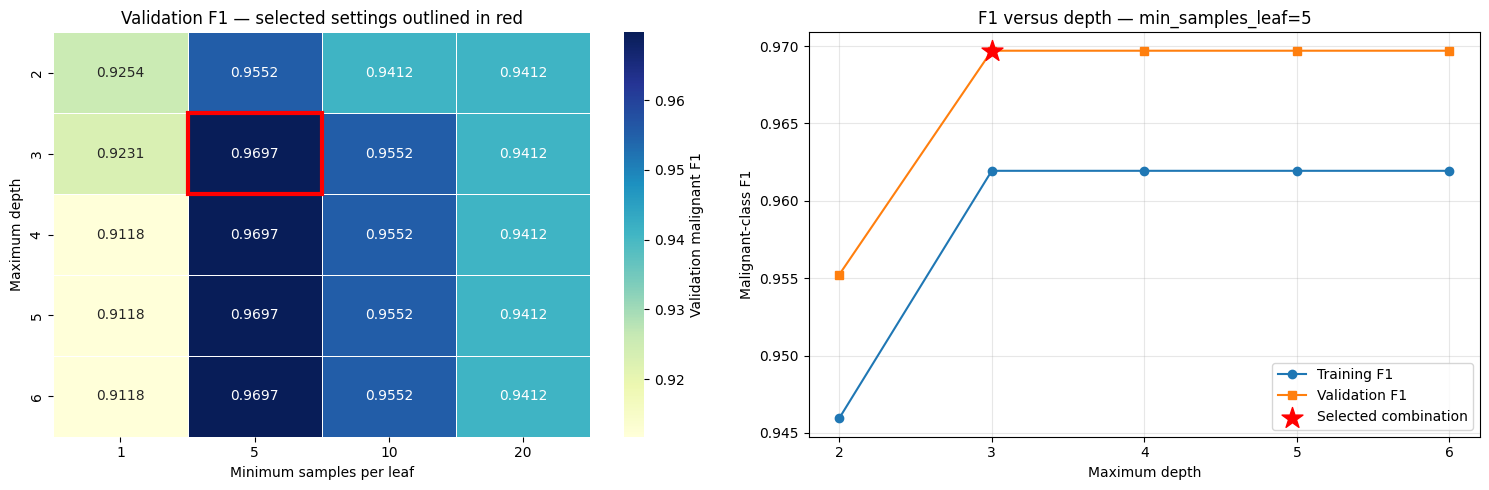

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ----- Plot 1: Validation F1 for every parameter combination -----
f1_grid = dt_tuning_results.pivot(
    index="Max depth",
    columns="Min samples leaf",
    values="Validation F1"
).reindex(index=depth_candidates, columns=leaf_candidates)

sns.heatmap(
    f1_grid,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Validation malignant F1"},
    ax=axes[0]
)

# Outline the selected combination.
selected_row = depth_candidates.index(best_depth)
selected_column = leaf_candidates.index(best_leaf_size)

axes[0].add_patch(Rectangle(
    (selected_column, selected_row),
    1, 1,
    fill=False,
    edgecolor="red",
    linewidth=3
))

axes[0].set_title("Validation F1 — selected settings outlined in red")
axes[0].set_xlabel("Minimum samples per leaf")
axes[0].set_ylabel("Maximum depth")

# ----- Plot 2: Vary depth while holding leaf size fixed -----
depth_results = dt_tuning_results[
    dt_tuning_results["Min samples leaf"] == best_leaf_size
].sort_values("Max depth")

axes[1].plot(
    depth_results["Max depth"],
    depth_results["Training F1"],
    marker="o",
    label="Training F1"
)

axes[1].plot(
    depth_results["Max depth"],
    depth_results["Validation F1"],
    marker="s",
    label="Validation F1"
)

best_val_f1 = float(dt_tuning_results.loc[0, "Validation F1"])

axes[1].scatter(
    best_depth,
    best_val_f1,
    marker="*",
    s=250,
    color="red",
    zorder=5,
    label="Selected combination"
)

axes[1].set_title(
    f"F1 versus depth — min_samples_leaf={best_leaf_size}"
)
axes[1].set_xlabel("Maximum depth")
axes[1].set_ylabel("Malignant-class F1")
axes[1].set_xticks(depth_candidates)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Results and Interpretation — Decision Tree Tuning

Twenty parameter combinations were evaluated. The selected settings were
max_depth=3 and min_samples_leaf=5, matching the initial model.

With min_samples_leaf=5, validation F1 increased from 0.9552 at depth 2
to 0.9697 at depth 3, then remained unchanged through depth 6.
Training F1 also remained unchanged at 0.9619 from depths 3 to 6.

Therefore, the depth curve shows a performance plateau. Deeper trees
added leaves without improving these F1 scores. The predefined tie-break
selected depth 3 as the more restrictive configuration.

The full tuning table also shows an overfitting pattern when
min_samples_leaf=1: training F1 increased to 1.0000 at depth 6, while
validation F1 was only 0.9118. This pattern concerns the leaf-size-1
candidates, not the plotted leaf-size-5 curve.

The selected model's validation F1 was slightly higher than its training
F1. This can occur because the splits contain different samples; it does
not itself indicate data leakage or an error.

Tuning did not improve on the initial model. It supported retaining its
settings within the tested grid. The selected fitted model is stored as
dt_library_final. Test results were not used for selection.

### 27. Library Decision Tree — Final Test Evaluation

We evaluate the selected Decision Tree on the same 86 test samples
used for the final Logistic Regression evaluation.

The tree remains fitted on the 398 training samples, with:
- max_depth=3
- min_samples_leaf=5
- criterion="gini"

We use the original, unscaled test features without fitting the model again.

Malignant (label 0) is treated as the positive class. We report accuracy,
malignant-class precision, recall, F1, ROC-AUC, and a confusion matrix.

These results provide the final held-out evaluation of this fitted tree.
They will not be used to change its settings or prediction rule.

Selected max_depth: 3
Selected min_samples_leaf: 5
Test samples: 86


,Metric,Test score
0,Accuracy,0.8953
1,Precision — malignant,0.8966
2,Recall — malignant,0.8125
3,F1 — malignant,0.8525
4,ROC-AUC — malignant,0.9010


True positives — malignant correctly identified: 26
False negatives — malignant predicted as benign: 6
False positives — benign predicted as malignant: 3
True negatives — benign correctly identified: 51


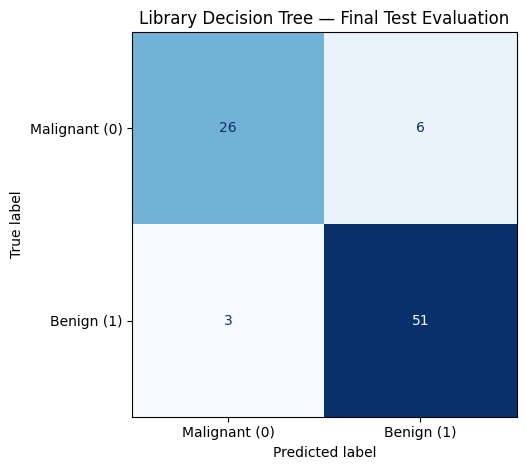

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predict with the selected, already-fitted tree.
# Do not call fit again or standardize the test features.
y_test_pred_dt = dt_library_final.predict(X_test)
y_test_proba_dt = dt_library_final.predict_proba(X_test)

# Locate the malignant probability column.
malignant_column_dt = np.flatnonzero(
    dt_library_final.classes_ == 0
).item()

p_test_malignant_dt = y_test_proba_dt[:, malignant_column_dt]

# Temporary target for malignant-class ROC-AUC.
# The original y_test remains unchanged.
y_test_malignant = (np.asarray(y_test) == 0).astype(int)

test_metrics_dt = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision — malignant",
        "Recall — malignant",
        "F1 — malignant",
        "ROC-AUC — malignant"
    ],
    "Test score": [
        accuracy_score(y_test, y_test_pred_dt),
        precision_score(
            y_test, y_test_pred_dt, pos_label=0, zero_division=0
        ),
        recall_score(
            y_test, y_test_pred_dt, pos_label=0, zero_division=0
        ),
        f1_score(
            y_test, y_test_pred_dt, pos_label=0, zero_division=0
        ),
        roc_auc_score(y_test_malignant, p_test_malignant_dt)
    ]
})

print("Selected max_depth:", dt_library_final.max_depth)
print("Selected min_samples_leaf:", dt_library_final.min_samples_leaf)
print("Test samples:", len(y_test))
display(test_metrics_dt.round(4))

# Rows = actual; columns = predicted.
# Malignant-first ordering gives [[TP, FN], [FP, TN]].
cm_test_dt = confusion_matrix(
    y_test, y_test_pred_dt, labels=[0, 1]
)
tp_test_dt, fn_test_dt, fp_test_dt, tn_test_dt = cm_test_dt.ravel()

print("True positives — malignant correctly identified:", tp_test_dt)
print("False negatives — malignant predicted as benign:", fn_test_dt)
print("False positives — benign predicted as malignant:", fp_test_dt)
print("True negatives — benign correctly identified:", tn_test_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test_dt,
    display_labels=["Malignant (0)", "Benign (1)"]
).plot(cmap="Blues", values_format="d", colorbar=False)

plt.title("Library Decision Tree — Final Test Evaluation")
plt.tight_layout()
plt.show()

### Results and Interpretation — Decision Tree Final Test Evaluation

The selected Decision Tree, with max_depth=3 and min_samples_leaf=5,
was evaluated on 86 test samples. Malignant (label 0) was treated as
the positive class.

#### Confusion Matrix Results

- **True positives: 26** — malignant samples correctly identified.
- **False negatives: 6** — malignant samples incorrectly predicted as benign.
- **False positives: 3** — benign samples incorrectly predicted as malignant.
- **True negatives: 51** — benign samples correctly identified.

#### Metric Calculations

| Metric | Calculation | Test result |
|---|---|---:|
| Accuracy | (26 + 51) / 86 | 89.53% |
| Malignant precision | 26 / (26 + 3) | 89.66% |
| Malignant recall | 26 / (26 + 6) | 81.25% |
| Malignant F1 | 52 / (52 + 3 + 6) | 85.25% |
| Malignant ROC-AUC | Calculated from malignant probability scores | 0.9010 |

#### Interpretation

The tree correctly classified 77 of 86 test samples. It missed 6 of
32 malignant samples and incorrectly labeled 3 benign samples as malignant.

Validation F1 was 96.97%, compared with test F1 of 85.25%. This substantial
drop shows that the validation result did not fully carry over to the
held-out test set. Differences between the small splits and selection
among multiple candidates may contribute. These results alone do not
establish a single cause.

Logistic Regression achieved higher scores on every reported test metric
and missed fewer malignant samples on the same test set: 2 versus 6.
It therefore performed better in this experiment, although one split
does not establish universal superiority.



# Task 3 (Implementing from Scratch):

# Task 3 — Implementing Classifiers from Scratch

### 28. Logistic Regression from Scratch

We implement feature standardization and Logistic Regression using NumPy.
No prebuilt classifier, scaler, or optimizer is used in this implementation.

We retain the existing data splits and original target encoding:
- 0 = malignant
- 1 = benign

The model computes:

z = Xw + b
p = sigmoid(z)

Here, p represents P(benign). The malignant probability is 1 − p.
Malignant remains our positive class when calculating evaluation metrics.

#### Training Objective

We minimize:

J = mean binary cross-entropy + (λ / 2) × sum(w²)

To match the selected library model, we use C = 0.1 and λ = 1 / (n × C),
where n is the number of training samples. The intercept is not penalized.

The gradients are:

gradient_w = Xᵀ(p − y) / n + λw
gradient_b = mean(p − y)

Full-batch gradient descent updates the parameters:

w = w − learning_rate × gradient_w
b = b − learning_rate × gradient_b

We initialize parameters to zero and stop when the largest absolute
gradient component is at most 1e-6, or after 20,000 updates.

We carry over the regularization setting selected using validation data.
No settings are selected using the previously observed test results.

In [28]:
import numpy as np

# Independent arrays preserve the original training data.
X_train_scratch_raw = np.asarray(X_train, dtype=np.float64).copy()
y_train_scratch = np.asarray(y_train, dtype=np.float64).copy()

# Learn scaling statistics from training data only.
scratch_mean = X_train_scratch_raw.mean(axis=0)
scratch_std = X_train_scratch_raw.std(axis=0, ddof=0)

# Protect against division by zero for constant features.
scratch_scale = np.where(scratch_std == 0.0, 1.0, scratch_std)

def standardize_for_scratch(X):
    """Apply the fixed training-set scaling statistics."""
    return (np.asarray(X, dtype=np.float64) - scratch_mean) / scratch_scale

X_train_scratch = standardize_for_scratch(X_train_scratch_raw)

assert np.isfinite(X_train_scratch).all()
assert np.array_equal(np.unique(y_train_scratch), [0, 1])

print("Training feature shape:", X_train_scratch.shape)
print("Training target shape:", y_train_scratch.shape)
print("Scaling calculated using training samples only.")

Training feature shape: (398, 30)
Training target shape: (398,)
Scaling calculated using training samples only.


### Logistic Regression — Scratch Class Implementation

We implement the following operations using NumPy:

1. Calculate the linear score: z = Xw + b.
2. Apply sigmoid to estimate P(benign).
3. Calculate mean binary cross-entropy with L2 regularization.
4. Calculate gradients and update parameters using gradient descent.
5. Stop when the largest absolute gradient is sufficiently small or
   the maximum number of updates is reached.
6. Generate probabilities and predicted class labels.

We use λ = 1 / (n × C) to match the library model's regularization
convention. The intercept is not penalized.

The class expects features already standardized using training statistics.

In [29]:
class LogisticRegressionScratch:
    def __init__(
        self, C=0.1, learning_rate=0.1,
        max_iter=20000, tolerance=1e-6
    ):
        self.C = C
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.tolerance = tolerance

    @staticmethod
    def _sigmoid(z):
        """Calculate sigmoid while avoiding exponential overflow."""
        p = np.empty_like(z, dtype=np.float64)
        positive = z >= 0

        p[positive] = 1.0 / (1.0 + np.exp(-z[positive]))

        exp_z = np.exp(z[~positive])
        p[~positive] = exp_z / (1.0 + exp_z)
        return p

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError("Expected X shaped (n, p) and y shaped (n,).")
        if len(y) == 0 or not np.isfinite(X).all():
            raise ValueError("Training inputs must be nonempty and finite.")
        if not np.array_equal(np.unique(y), [0, 1]):
            raise ValueError("Training labels must contain both 0 and 1.")
        if self.C <= 0 or self.learning_rate <= 0:
            raise ValueError("C and learning_rate must be positive.")

        n_samples, n_features = X.shape

        # Initialize model parameters.
        self.lambda_ = 1.0 / (n_samples * self.C)
        self.weights_ = np.zeros(n_features)
        self.bias_ = 0.0
        self.classes_ = np.array([0, 1])
        self.loss_history_ = []
        self.converged_ = False

        for iteration in range(self.max_iter + 1):
            logits = X @ self.weights_ + self.bias_
            probabilities = self._sigmoid(logits)

            # Stable mean cross-entropy plus L2 penalty.
            data_loss = np.mean(
                np.logaddexp(0.0, logits) - y * logits
            )
            penalty = 0.5 * self.lambda_ * np.sum(self.weights_ ** 2)
            loss = data_loss + penalty

            if not np.isfinite(loss):
                raise FloatingPointError("Non-finite training loss.")

            self.loss_history_.append(float(loss))

            # Gradients: regularize weights, but not the intercept.
            errors = probabilities - y
            gradient_w = (
                X.T @ errors / n_samples
                + self.lambda_ * self.weights_
            )
            gradient_b = errors.mean()

            self.gradient_max_ = float(max(
                np.max(np.abs(gradient_w)),
                abs(gradient_b)
            ))
            self.n_iter_ = iteration

            if self.gradient_max_ <= self.tolerance:
                self.converged_ = True
                break

            if iteration == self.max_iter:
                break

            self.weights_ -= self.learning_rate * gradient_w
            self.bias_ -= self.learning_rate * gradient_b

        return self

    def decision_function(self, X):
        """Calculate linear scores for standardized inputs."""
        X = np.asarray(X, dtype=np.float64)
        return X @ self.weights_ + self.bias_

    def predict_proba(self, X):
        """Return columns [P(malignant), P(benign)]."""
        p_benign = self._sigmoid(self.decision_function(X))
        return np.column_stack((1.0 - p_benign, p_benign))

    def predict(self, X):
        """Predict benign for positive scores; otherwise malignant."""
        return (self.decision_function(X) > 0.0).astype(int)


print("Scratch Logistic Regression class defined. Training has not started.")

Scratch Logistic Regression class defined. Training has not started.


### 28.1. Scratch Logistic Regression — Training

We train our NumPy implementation using 398 standardized training samples.

Settings:
- C = 0.1, matching the selected library model.
- Learning rate = 0.1.
- Maximum gradient-descent updates = 20,000.
- Convergence tolerance = 1e-6.

Training stops when the largest absolute gradient component is at most
the tolerance, or when the update limit is reached.

The plotted objective includes mean binary cross-entropy and the L2 penalty.
A decreasing objective indicates optimization progress; predictive
performance will be assessed separately.

Validation and test data are not used during training.

Scratch Logistic Regression training completed.
Training samples: 398
Features: 30
C: 0.1
Equivalent lambda: 0.02512563
Gradient-descent updates: 3113
Convergence criterion met: True
Initial objective: 0.693147
Final objective: 0.124719
Largest absolute gradient: 0.00000100


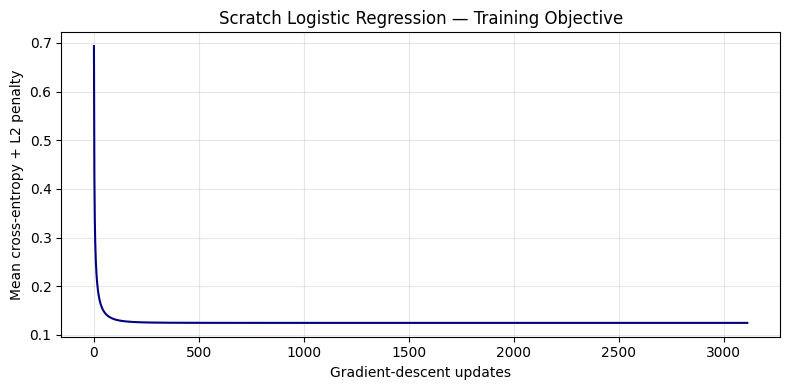

Validation and test data were not used during training.


In [30]:
import matplotlib.pyplot as plt

# Create and train our own classifier.
lr_scratch = LogisticRegressionScratch(
    C=0.1,
    learning_rate=0.1,
    max_iter=20000,
    tolerance=1e-6
)

lr_scratch.fit(X_train_scratch, y_train_scratch)

# Inspect optimization results.
print("Scratch Logistic Regression training completed.")
print("Training samples:", len(y_train_scratch))
print("Features:", X_train_scratch.shape[1])
print("C:", lr_scratch.C)
print(f"Equivalent lambda: {lr_scratch.lambda_:.8f}")
print("Gradient-descent updates:", lr_scratch.n_iter_)
print("Convergence criterion met:", lr_scratch.converged_)
print(f"Initial objective: {lr_scratch.loss_history_[0]:.6f}")
print(f"Final objective: {lr_scratch.loss_history_[-1]:.6f}")
print(f"Largest absolute gradient: {lr_scratch.gradient_max_:.8f}")

if not lr_scratch.converged_:
    print("Iteration limit reached; optimization needs inspection.")

# Plot the objective recorded at each update.
plt.figure(figsize=(8, 4))
plt.plot(lr_scratch.loss_history_, color="navy")
plt.xlabel("Gradient-descent updates")
plt.ylabel("Mean cross-entropy + L2 penalty")
plt.title("Scratch Logistic Regression — Training Objective")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Validation and test data were not used during training.")

### Results and Interpretation — Scratch Logistic Regression Training

The NumPy implementation was trained using 398 samples and 30 standardized
features. It used C = 0.1, equivalent to λ = 0.02512563 in our mean-loss
formulation.

Gradient descent met the convergence criterion after 3,113 updates,
before reaching the limit of 20,000.

The initial objective was 0.693147. With zero-initialized weights and
intercept, every sample initially receives a probability of 0.5, and
the regularization penalty is zero.

The final objective was 0.124719. This value includes both mean binary
cross-entropy and the L2 penalty; it is not an error rate or accuracy.

The largest absolute gradient component met the 1e-6 tolerance.
Its printed value is rounded, explaining why it appears as 0.00000100.

The library model uses L-BFGS, whereas this implementation uses full-batch
gradient descent. Their iteration counts are therefore not directly
comparable measures of computational efficiency.

These results indicate successful optimization under our stopping rule.
Validation evaluation and comparison with the library model are still
needed to assess predictions and implementation agreement.

Validation and test data were not used during training.

### 29. Scratch Logistic Regression — Validation Evaluation

We standardize validation features using the means and standard deviations
previously calculated from training data. Neither the scaler nor the model
is fitted again.

Malignant (label 0) is treated as the positive class.

We calculate evaluation metrics directly from the predictions:

- Accuracy = (TP + TN) / total samples
- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)
- F1 = 2TP / (2TP + FP + FN)

If a precision, recall, or F1 denominator is zero, we return zero,
matching the convention used in our library evaluations.

For ROC-AUC, we compare every malignant sample's probability score with
every benign sample's score. A correctly ordered pair receives 1 point,
a tied pair receives 0.5 points, and an incorrectly ordered pair receives
0 points. AUC is the average across all pairs.

All metric calculations use NumPy. Pandas and Matplotlib are used only
to display results. Test data are not evaluated in this step.

,Metric,Validation score
0,Accuracy,0.9882
1,Precision — malignant,0.9697
2,Recall — malignant,1.0000
3,F1 — malignant,0.9846
4,ROC-AUC — malignant,0.9988


Validation samples: 85
True positives — malignant correctly identified: 32
False negatives — malignant predicted as benign: 0
False positives — benign predicted as malignant: 1
True negatives — benign correctly identified: 52


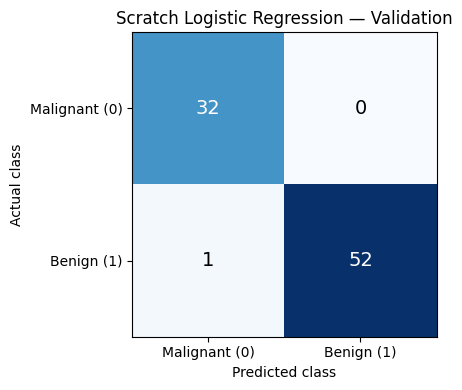

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_binary_scratch(y_true, y_pred, p_malignant):
    """Calculate metrics with malignant (label 0) as positive."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    p_malignant = np.asarray(p_malignant, dtype=np.float64)

    # Check shapes, labels, and probability values.
    if not (
        y_true.ndim == y_pred.ndim == p_malignant.ndim == 1
        and y_true.size == y_pred.size == p_malignant.size
        and y_true.size > 0
    ):
        raise ValueError("Inputs must be matching nonempty 1D arrays.")

    if not (
        np.isin(y_true, [0, 1]).all()
        and np.isin(y_pred, [0, 1]).all()
    ):
        raise ValueError("Expected labels 0 and 1.")

    if not (
        np.isfinite(p_malignant).all()
        and ((p_malignant >= 0) & (p_malignant <= 1)).all()
    ):
        raise ValueError("Probabilities must be finite and between 0 and 1.")

    # Count outcomes directly.
    tp = int(np.sum((y_true == 0) & (y_pred == 0)))
    fn = int(np.sum((y_true == 0) & (y_pred == 1)))
    fp = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 1) & (y_pred == 1)))

    accuracy = (tp + tn) / y_true.size
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 0.0

    # Pairwise ROC-AUC; appropriate for our small evaluation sets.
    malignant_scores = p_malignant[y_true == 0]
    benign_scores = p_malignant[y_true == 1]

    if malignant_scores.size == 0 or benign_scores.size == 0:
        auc = np.nan  # AUC requires both classes.
    else:
        differences = (
            malignant_scores[:, None] - benign_scores[None, :]
        )
        auc = float(np.mean(
            (differences > 0).astype(float)
            + 0.5 * (differences == 0)
        ))

    scores = {
        "Accuracy": accuracy,
        "Precision — malignant": precision,
        "Recall — malignant": recall,
        "F1 — malignant": f1,
        "ROC-AUC — malignant": auc
    }

    # Rows = actual; columns = predicted; malignant first.
    matrix = np.array([[tp, fn], [fp, tn]])
    return scores, matrix


# Apply existing TRAINING statistics to validation features.
X_val_scratch = standardize_for_scratch(X_val)

# Predict using our trained NumPy classifier.
y_val_pred_lr_scratch = lr_scratch.predict(X_val_scratch)

malignant_column_scratch = np.flatnonzero(
    lr_scratch.classes_ == 0
).item()

p_val_malignant_lr_scratch = lr_scratch.predict_proba(
    X_val_scratch
)[:, malignant_column_scratch]

# Calculate metrics without sklearn.metrics.
val_scores_lr_scratch, cm_val_lr_scratch = evaluate_binary_scratch(
    y_val,
    y_val_pred_lr_scratch,
    p_val_malignant_lr_scratch
)

validation_metrics_lr_scratch = pd.DataFrame({
    "Metric": list(val_scores_lr_scratch.keys()),
    "Validation score": list(val_scores_lr_scratch.values())
})

display(validation_metrics_lr_scratch.round(4))

tp, fn, fp, tn = cm_val_lr_scratch.ravel()
print("Validation samples:", len(y_val))
print("True positives — malignant correctly identified:", tp)
print("False negatives — malignant predicted as benign:", fn)
print("False positives — benign predicted as malignant:", fp)
print("True negatives — benign correctly identified:", tn)

# Draw the confusion matrix using Matplotlib.
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_val_lr_scratch, cmap="Blues", vmin=0)

labels = ["Malignant (0)", "Benign (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Scratch Logistic Regression — Validation")

for row in range(2):
    for column in range(2):
        value = cm_val_lr_scratch[row, column]
        color = "white" if value > cm_val_lr_scratch.max() / 2 else "black"
        ax.text(
            column, row, str(value),
            ha="center", va="center", color=color, fontsize=14
        )

plt.tight_layout()
plt.show()

### Results and Interpretation — Scratch Logistic Regression Validation

The scratch implementation correctly classified 84 of 85 validation samples.

With malignant as the positive class, the confusion-matrix counts were:
- True positives: 32
- False negatives: 0
- False positives: 1
- True negatives: 52

All malignant samples were identified. One benign sample was incorrectly
predicted as malignant.

Accuracy was 98.82%, malignant precision was 96.97%, recall was 100%,
F1 was 98.46%, and ROC-AUC was 0.9988.

These metrics match the selected library model (C = 0.1) to the displayed
precision. The implementations also produced the same confusion-matrix
counts, supporting consistency between their results.

However, matching aggregate metrics does not prove that every individual
prediction or probability is identical. We will next compare predictions
and probability scores directly.

No parameters were updated during this evaluation, and test data were
not evaluated in this step.

### 30. Logistic Regression — Library versus Scratch Agreement

Matching aggregate metrics does not necessarily mean that two models make
the same prediction for every sample.

We compare both fitted implementations on the same validation samples:

- Number and percentage of matching class predictions.
- Number of prediction disagreements.
- Mean and maximum absolute differences in malignant probabilities.

Both implementations use C = 0.1 and training-only standardization.
However, the library model uses L-BFGS while the scratch model uses gradient
descent, so small numerical differences are expected.

The probability scatter plot includes an equality line. Points near this
line indicate similar probability estimates. This is an implementation
agreement plot, not a probability-calibration assessment.

The library model serves only as a comparison reference. Its parameters
or predictions are not used to train the scratch model.

Validation samples: 85
Matching class predictions: 85
Prediction disagreements: 0
Prediction agreement: 100.00%
Mean absolute probability difference: 0.0000012322
Maximum absolute probability difference: 0.0000111175

Both models predict the same class for every validation sample.


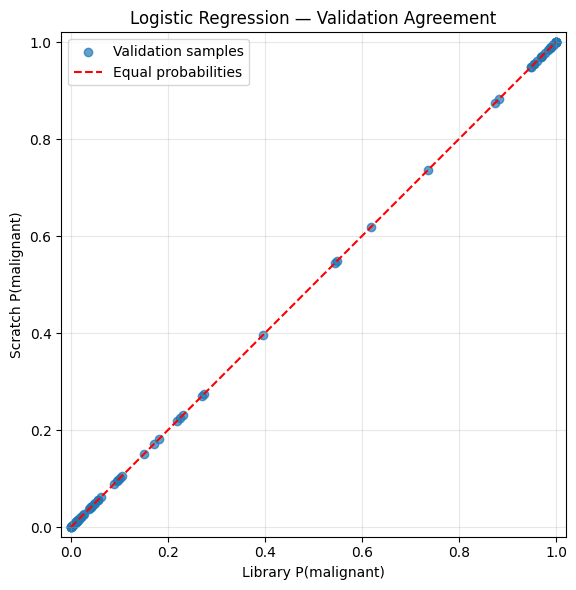

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confirm that the regularization settings match.
library_classifier = lr_library_final.named_steps["classifier"]
assert np.isclose(library_classifier.C, lr_scratch.C), "C values differ."

# Library pipeline receives ORIGINAL validation features.
library_val_predictions = lr_library_final.predict(X_val)
library_malignant_column = np.flatnonzero(
    library_classifier.classes_ == 0
).item()
library_val_probabilities = lr_library_final.predict_proba(
    X_val
)[:, library_malignant_column]

# Scratch model receives features standardized using its training statistics.
scratch_val_features = standardize_for_scratch(X_val)
scratch_val_predictions = lr_scratch.predict(scratch_val_features)
scratch_malignant_column = np.flatnonzero(
    lr_scratch.classes_ == 0
).item()
scratch_val_probabilities = lr_scratch.predict_proba(
    scratch_val_features
)[:, scratch_malignant_column]

# Compare corresponding samples in the same order.
agreement = library_val_predictions == scratch_val_predictions
probability_difference = np.abs(
    library_val_probabilities - scratch_val_probabilities
)

print("Validation samples:", len(X_val))
print("Matching class predictions:", int(agreement.sum()))
print("Prediction disagreements:", int((~agreement).sum()))
print(f"Prediction agreement: {agreement.mean() * 100:.2f}%")
print(
    "Mean absolute probability difference:",
    f"{probability_difference.mean():.10f}"
)
print(
    "Maximum absolute probability difference:",
    f"{probability_difference.max():.10f}"
)

# Show any samples receiving different predicted labels.
lr_validation_agreement = pd.DataFrame({
    "Actual label": np.asarray(y_val),
    "Library prediction": library_val_predictions,
    "Scratch prediction": scratch_val_predictions,
    "Library P(malignant)": library_val_probabilities,
    "Scratch P(malignant)": scratch_val_probabilities,
    "Absolute difference": probability_difference
}, index=X_val.index)

if (~agreement).any():
    print("\nSamples with prediction disagreements:")
    display(lr_validation_agreement.loc[~agreement])
else:
    print("\nBoth models predict the same class for every validation sample.")

# Compare probability estimates visually.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    library_val_probabilities,
    scratch_val_probabilities,
    alpha=0.7,
    label="Validation samples"
)
ax.plot([0, 1], [0, 1], "r--", label="Equal probabilities")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Library P(malignant)")
ax.set_ylabel("Scratch P(malignant)")
ax.set_title("Logistic Regression — Validation Agreement")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation — Library versus Scratch Agreement

Both implementations produced identical class predictions for all **85 validation samples**, achieving **100% agreement**.

Malignant probability estimates were also very close:
- **Mean absolute difference:** 0.0000012322
- **Maximum absolute difference:** 0.0000111175

These results support numerical consistency between the scratch and library implementations. The small differences are consistent with their different optimizers and stopping criteria.

**Agreement is not accuracy:** both models made the same one classification error, giving **98.82% validation accuracy**.

### 31. Scratch Logistic Regression — Final Test Evaluation

We evaluate the fixed scratch model on the same 86 test samples used
for the library models. Test features are standardized using training
statistics only.

We retain C = 0.1 and the existing prediction rule. No retraining or
further tuning is performed. Metrics are calculated using our NumPy
evaluation function, with malignant (label 0) as the positive class.

Test samples: 86
C: 0.1


,Metric,Test score
0,Accuracy,0.9767
1,Precision — malignant,1.0000
2,Recall — malignant,0.9375
3,F1 — malignant,0.9677
4,ROC-AUC — malignant,0.9936


True positives: 30
False negatives: 2
False positives: 0
True negatives: 54


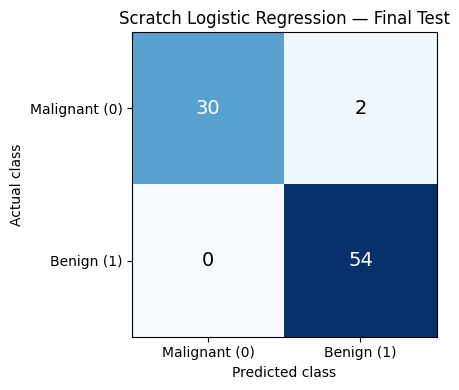

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply training-set scaling; do not recalculate statistics.
X_test_scratch = standardize_for_scratch(X_test)

# Predict using the already-trained scratch model.
y_test_pred_lr_scratch = lr_scratch.predict(X_test_scratch)

malignant_column = np.flatnonzero(lr_scratch.classes_ == 0).item()
p_test_malignant_lr_scratch = lr_scratch.predict_proba(
    X_test_scratch
)[:, malignant_column]

# Reuse our NumPy metric implementation.
test_scores_lr_scratch, cm_test_lr_scratch = evaluate_binary_scratch(
    y_test,
    y_test_pred_lr_scratch,
    p_test_malignant_lr_scratch
)

test_metrics_lr_scratch = pd.DataFrame({
    "Metric": list(test_scores_lr_scratch.keys()),
    "Test score": list(test_scores_lr_scratch.values())
})

print("Test samples:", len(y_test))
print("C:", lr_scratch.C)
display(test_metrics_lr_scratch.round(4))

# Matrix order: [[TP, FN], [FP, TN]].
tp, fn, fp, tn = cm_test_lr_scratch.ravel()
print("True positives:", tp)
print("False negatives:", fn)
print("False positives:", fp)
print("True negatives:", tn)

# Plot without sklearn.
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_test_lr_scratch, cmap="Blues", vmin=0)

labels = ["Malignant (0)", "Benign (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Scratch Logistic Regression — Final Test")

for row in range(2):
    for column in range(2):
        value = cm_test_lr_scratch[row, column]
        color = "white" if value > cm_test_lr_scratch.max() / 2 else "black"
        ax.text(
            column, row, str(value),
            ha="center", va="center", color=color, fontsize=14
        )

plt.tight_layout()
plt.show()

### Interpretation — Scratch Logistic Regression Test Results

The scratch model correctly classified **84 of 86 test samples**:

- **Accuracy:** 97.67%
- **Malignant precision:** 100%
- **Malignant recall:** 93.75%
- **Malignant F1:** 96.77%
- **ROC-AUC:** 0.9936

It identified **30 of 32 malignant samples**, missing **2**, and correctly
classified all **54 benign samples**. Perfect precision therefore does
not mean that every malignant sample was detected.

The metrics match the selected library model to the displayed precision,
with identical confusion-matrix counts. This supports consistency between
the implementations, although individual test-prediction agreement has
not been checked.

No settings were changed using these test results.

### 32. Decision Tree from Scratch

We implement a binary classification tree using NumPy and the original,
unscaled features.

At each node, the algorithm:
1. Considers thresholds halfway between consecutive unique feature values.
2. Rejects splits that would create a child with fewer than five samples.
3. Selects the split with the greatest reduction in weighted Gini impurity.
4. Repeats recursively until a stopping condition is reached.

Gini impurity = 1 − p₀² − p₁²

Splitting stops at depth 3, when the node is pure, or when no valid
impurity-reducing split exists. Root depth is zero.

Each leaf stores its class proportions and predicts the majority class.
A tied class vote predicts label 0. Exactly tied split gains retain
the first candidate encountered in feature and threshold order.

The library and scratch trees use comparable settings, but numerical
precision and split tie-breaking can produce different trees.

In [34]:
import numpy as np

class DecisionTreeScratch:
    def __init__(self, max_depth=3, min_samples_leaf=5):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    @staticmethod
    def _gini(y):
        """Class mixing for labels 0 and 1."""
        proportions = np.bincount(y, minlength=2) / len(y)
        return 1.0 - np.sum(proportions ** 2)

    def _best_split(self, X, y):
        n_samples, n_features = X.shape
        parent_gini = self._gini(y)

        best_gain = 0.0
        best_split = None

        for feature in range(n_features):
            values = np.unique(X[:, feature])
            thresholds = values[:-1] + np.diff(values) / 2.0

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                n_left = int(left_mask.sum())
                n_right = n_samples - n_left

                # Both children must meet the minimum leaf size.
                if (
                    n_left < self.min_samples_leaf
                    or n_right < self.min_samples_leaf
                ):
                    continue

                weighted_gini = (
                    n_left / n_samples * self._gini(y[left_mask])
                    + n_right / n_samples * self._gini(y[~left_mask])
                )
                gain = parent_gini - weighted_gini

                # Strict improvement retains the first exact tie.
                if gain > best_gain:
                    best_gain = gain
                    best_split = (feature, float(threshold), left_mask)

        return best_split

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=2)

        node = {
            "samples": len(y),
            "gini": self._gini(y),
            "probabilities": counts / len(y),
            "prediction": int(np.argmax(counts)),
            "depth": depth,
            "is_leaf": True
        }

        self.n_nodes_ += 1
        self.depth_ = max(self.depth_, depth)

        # Stop at the depth limit, a pure node, or insufficient samples.
        if (
            depth >= self.max_depth
            or np.count_nonzero(counts) == 1
            or len(y) < 2 * self.min_samples_leaf
        ):
            self.n_leaves_ += 1
            return node

        split = self._best_split(X, y)

        if split is None:
            self.n_leaves_ += 1
            return node

        feature, threshold, left_mask = split

        node["is_leaf"] = False
        node["feature"] = feature
        node["threshold"] = threshold
        node["left"] = self._grow(
            X[left_mask], y[left_mask], depth + 1
        )
        node["right"] = self._grow(
            X[~left_mask], y[~left_mask], depth + 1
        )
        return node

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)

        if X.ndim != 2 or y.ndim != 1 or len(X) != len(y):
            raise ValueError("Expected X shaped (n, p) and y shaped (n,).")
        if len(y) == 0 or X.shape[1] == 0 or not np.isfinite(X).all():
            raise ValueError("Training inputs must be nonempty and finite.")
        if not np.isin(y, [0, 1]).all():
            raise ValueError("Expected labels 0 and 1.")
        if not isinstance(self.max_depth, int) or self.max_depth < 0:
            raise ValueError("max_depth must be a nonnegative integer.")
        if (
            not isinstance(self.min_samples_leaf, int)
            or self.min_samples_leaf < 1
        ):
            raise ValueError("min_samples_leaf must be a positive integer.")

        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        self.n_nodes_ = 0
        self.n_leaves_ = 0
        self.depth_ = 0

        self.root_ = self._grow(X, y.astype(int), depth=0)
        return self

    def _find_leaf(self, sample):
        node = self.root_

        while not node["is_leaf"]:
            if sample[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]

        return node

    def predict_proba(self, X):
        """Columns: P(malignant=0), P(benign=1)."""
        X = np.asarray(X, dtype=np.float64)

        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("Prediction features must match training.")
        if not np.isfinite(X).all():
            raise ValueError("Prediction inputs must be finite.")

        return np.array([
            self._find_leaf(sample)["probabilities"] for sample in X
        ]).reshape(-1, 2)

    def predict(self, X):
        # np.argmax selects class 0 when probabilities tie.
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


print("Scratch Decision Tree class defined. Training has not started.")

Scratch Decision Tree class defined. Training has not started.


### 32.1. Scratch Decision Tree — Training

We fit our NumPy tree on 398 training samples and 30 unscaled features,
using max_depth=3 and min_samples_leaf=5.

These settings were selected through the earlier validation search.
The scratch tree learns its own splits from training data; it does not
copy the library tree's structure.

We inspect its depth, leaves, node count, and root split.
Validation and test data are not used during fitting.

In [35]:
# Create and fit the scratch tree.
dt_scratch = DecisionTreeScratch(
    max_depth=3,
    min_samples_leaf=5
)

dt_scratch.fit(X_train, y_train)

print("Scratch Decision Tree fitted.")
print("Training samples:", len(X_train))
print("Input features:", dt_scratch.n_features_in_)
print("Class order:", dt_scratch.classes_)
print("Actual tree depth:", dt_scratch.depth_)
print("Number of leaves:", dt_scratch.n_leaves_)
print("Total nodes:", dt_scratch.n_nodes_)

# Inspect the first learned decision rule.
root = dt_scratch.root_

if not root["is_leaf"]:
    root_feature = X_train.columns[root["feature"]]
    print(f"\nRoot split: {root_feature} <= {root['threshold']:.6f}")
    print(f"Root Gini impurity: {root['gini']:.6f}")
    print("Left-child training samples:", root["left"]["samples"])
    print("Right-child training samples:", root["right"]["samples"])
else:
    print("\nThe fitted tree consists of a single leaf.")

print("\nValidation and test data were not used during fitting.")

Scratch Decision Tree fitted.
Training samples: 398
Input features: 30
Class order: [0 1]
Actual tree depth: 3
Number of leaves: 7
Total nodes: 13

Root split: worst radius <= 16.795000
Root Gini impurity: 0.467160
Left-child training samples: 267
Right-child training samples: 131

Validation and test data were not used during fitting.


### Interpretation — Scratch Decision Tree Training

The scratch tree was fitted on **398 samples and 30 features**, producing
a depth of **3**, **7 leaves**, and **13 total nodes**.

Its first split is **worst radius ≤ 16.795**, sending 267 training samples
left and 131 right. This split produced the greatest weighted Gini
reduction among the valid root candidates considered.

The root Gini impurity of **0.467160** reflects the mixture of malignant
and benign samples before splitting.

The depth, leaf count, and node count match the library tree, but this
alone does not establish identical internal rules or predictions.
Validation evaluation is needed next.

### 33. Scratch Decision Tree — Validation Evaluation

We evaluate the fitted scratch tree on the 85 original, unscaled validation
samples. No retraining is performed.

Our NumPy evaluation function calculates accuracy, precision, recall, F1,
ROC-AUC, and confusion-matrix counts, treating malignant (label 0) as
the positive class. Test data are not evaluated in this step.

,Metric,Validation score
0,Accuracy,0.9765
1,Precision — malignant,0.9412
2,Recall — malignant,1.0000
3,F1 — malignant,0.9697
4,ROC-AUC — malignant,0.9885


Validation samples: 85
True positives: 32
False negatives: 0
False positives: 2
True negatives: 51


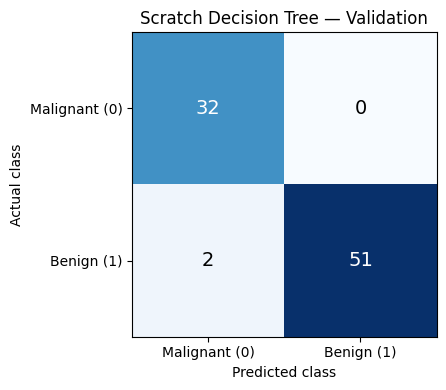

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict using original, unscaled validation features.
y_val_pred_dt_scratch = dt_scratch.predict(X_val)

malignant_column = np.flatnonzero(dt_scratch.classes_ == 0).item()
p_val_malignant_dt_scratch = dt_scratch.predict_proba(
    X_val
)[:, malignant_column]

# Reuse our NumPy metric function.
val_scores_dt_scratch, cm_val_dt_scratch = evaluate_binary_scratch(
    y_val,
    y_val_pred_dt_scratch,
    p_val_malignant_dt_scratch
)

validation_metrics_dt_scratch = pd.DataFrame({
    "Metric": list(val_scores_dt_scratch.keys()),
    "Validation score": list(val_scores_dt_scratch.values())
})

display(validation_metrics_dt_scratch.round(4))

# Matrix order: [[TP, FN], [FP, TN]].
tp, fn, fp, tn = cm_val_dt_scratch.ravel()
print("Validation samples:", len(y_val))
print("True positives:", tp)
print("False negatives:", fn)
print("False positives:", fp)
print("True negatives:", tn)

# Draw the confusion matrix without sklearn.
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_val_dt_scratch, cmap="Blues", vmin=0)

labels = ["Malignant (0)", "Benign (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Scratch Decision Tree — Validation")

for row in range(2):
    for column in range(2):
        value = cm_val_dt_scratch[row, column]
        color = "white" if value > cm_val_dt_scratch.max() / 2 else "black"
        ax.text(
            column, row, str(value),
            ha="center", va="center", color=color, fontsize=14
        )

plt.tight_layout()
plt.show()

### Interpretation — Scratch Decision Tree Validation

The scratch tree correctly classified **83 of 85 validation samples**.
It detected all **32 malignant samples**, with **0 false negatives**
and **2 false positives**.

- **Accuracy:** 97.65%
- **Malignant precision:** 94.12%
- **Malignant recall:** 100%
- **Malignant F1:** 96.97%
- **ROC-AUC:** 0.9885

These metrics match the selected library tree to the displayed precision,
with identical confusion-matrix counts. Individual prediction agreement
still needs to be checked; matching totals alone does not prove identical
predictions.

### 34. Decision Tree — Library versus Scratch Agreement

We compare individual validation predictions and malignant probabilities
from the selected library tree and the scratch tree.

Both use max_depth=3 and min_samples_leaf=5. Agreement is checked on the
same unscaled samples without retraining. Matching outputs on these
samples does not prove that the trees have identical internal rules.

In [37]:
import numpy as np
import pandas as pd

# Confirm matching complexity settings.
assert dt_library_final.max_depth == dt_scratch.max_depth
assert dt_library_final.min_samples_leaf == dt_scratch.min_samples_leaf

# Generate predictions in the same validation-sample order.
dt_library_val_pred = dt_library_final.predict(X_val)
dt_scratch_val_pred = dt_scratch.predict(X_val)

library_column = np.flatnonzero(
    dt_library_final.classes_ == 0
).item()
scratch_column = np.flatnonzero(
    dt_scratch.classes_ == 0
).item()

dt_library_val_prob = dt_library_final.predict_proba(
    X_val
)[:, library_column]
dt_scratch_val_prob = dt_scratch.predict_proba(
    X_val
)[:, scratch_column]

# Compare labels and probabilities.
dt_agreement = dt_library_val_pred == dt_scratch_val_pred
dt_probability_difference = np.abs(
    dt_library_val_prob - dt_scratch_val_prob
)

print("Validation samples:", len(X_val))
print("Matching class predictions:", int(dt_agreement.sum()))
print("Prediction disagreements:", int((~dt_agreement).sum()))
print(f"Prediction agreement: {dt_agreement.mean() * 100:.2f}%")
print(
    "Mean absolute probability difference:",
    f"{dt_probability_difference.mean():.10f}"
)
print(
    "Maximum absolute probability difference:",
    f"{dt_probability_difference.max():.10f}"
)

dt_validation_agreement = pd.DataFrame({
    "Actual label": np.asarray(y_val),
    "Library prediction": dt_library_val_pred,
    "Scratch prediction": dt_scratch_val_pred,
    "Library P(malignant)": dt_library_val_prob,
    "Scratch P(malignant)": dt_scratch_val_prob,
    "Absolute difference": dt_probability_difference
}, index=X_val.index)

if (~dt_agreement).any():
    print("\nSamples with prediction disagreements:")
    display(dt_validation_agreement.loc[~dt_agreement])
else:
    print("\nBoth trees predict the same class for every validation sample.")

Validation samples: 85
Matching class predictions: 85
Prediction disagreements: 0
Prediction agreement: 100.00%
Mean absolute probability difference: 0.0047058824
Maximum absolute probability difference: 0.2000000000

Both trees predict the same class for every validation sample.


### Interpretation — Decision Tree Agreement

Both trees predicted identical classes for all **85 validation samples**,
giving **100% prediction agreement**.

Their malignant probabilities differed:
- **Mean absolute difference:** 0.004706
- **Maximum absolute difference:** 0.20 (20 percentage points)

Thus, matching class predictions does not mean identical probability
estimates. Different leaf compositions can produce different probabilities
while retaining the same majority-class prediction.

The maximum difference is too large to describe as numerical rounding.
Inspecting the affected samples and their leaf assignments would help
explain it. Neither tree is changed based on this comparison.

### 34.1. Investigating Decision Tree Probability Differences

We inspect validation samples whose malignant probabilities differ between
implementations, comparing their decision paths, leaf sizes, and leaf
probabilities.

This helps distinguish differences in learned splits or sample routing
from a probability-calculation error. Neither model is retrained or changed.

In [38]:
# Find probability differences larger than negligible rounding.
different_positions = np.flatnonzero(dt_probability_difference > 1e-10)

# Identify the library leaf reached by each validation sample.
library_leaf_ids = dt_library_final.apply(X_val)
X_val_array = np.asarray(X_val, dtype=np.float64)
feature_names = list(X_train.columns)

inspection_rows = []

for position in different_positions:
    sample = X_val_array[position]

    # Library leaf information.
    leaf_id = library_leaf_ids[position]
    library_leaf_size = int(
        dt_library_final.tree_.n_node_samples[leaf_id]
    )

    # Normalize values to support counts or proportions.
    library_values = dt_library_final.tree_.value[leaf_id][0]
    library_leaf_prob = (
        library_values[library_column] / library_values.sum()
    )

    # Scratch leaf information.
    scratch_leaf = dt_scratch._find_leaf(sample)

    inspection_rows.append({
        "Sample index": X_val.index[position],
        "Actual label": np.asarray(y_val)[position],
        "Library prediction": dt_library_val_pred[position],
        "Scratch prediction": dt_scratch_val_pred[position],
        "Library leaf samples": library_leaf_size,
        "Scratch leaf samples": scratch_leaf["samples"],
        "Library P(malignant)": library_leaf_prob,
        "Scratch P(malignant)": scratch_leaf["probabilities"][scratch_column]
    })

print("Samples with probability differences:", len(different_positions))
display(pd.DataFrame(inspection_rows))

# Show the decision paths for each affected sample.
for position in different_positions:
    sample = X_val_array[position]
    print(f"\nSample index: {X_val.index[position]}")

    print("Library path:")
    path = dt_library_final.decision_path(X_val.iloc[[position]])
    for node_id in path.indices:
        feature = dt_library_final.tree_.feature[node_id]
        if feature >= 0:  # Internal decision node.
            threshold = dt_library_final.tree_.threshold[node_id]
            left_id = dt_library_final.tree_.children_left[node_id]
            went_left = left_id in path.indices
            direction = "<=" if went_left else ">"
            print(
                f"  {feature_names[feature]} {direction} "
                f"{threshold:.8f}"
            )

    print("Scratch path:")
    node = dt_scratch.root_
    while not node["is_leaf"]:
        feature = node["feature"]
        threshold = node["threshold"]
        went_left = sample[feature] <= threshold
        direction = "<=" if went_left else ">"
        print(
            f"  {feature_names[feature]} {direction} "
            f"{threshold:.8f}"
        )
        node = node["left"] if went_left else node["right"]

Samples with probability differences: 2


,Sample index,Actual label,Library prediction,Scratch prediction,Library leaf samples,Scratch leaf samples,Library P(malignant),Scratch P(malignant)
0,127,0,0,0,117,5,1.0,0.8
1,122,0,0,0,5,117,0.8,1.0



Sample index: 127
Library path:
  worst radius > 16.79500008
  mean texture > 14.99000025
  texture error <= 1.97599995
Scratch path:
  worst radius > 16.79500000
  mean texture > 14.99000000
  mean smoothness <= 0.08263000

Sample index: 122
Library path:
  worst radius > 16.79500008
  mean texture > 14.99000025
  texture error > 1.97599995
Scratch path:
  worst radius > 16.79500000
  mean texture > 14.99000000
  mean smoothness > 0.08263000


### Interpretation — Probability Differences Explained

The two trees use different third-level splits in the inspected branch:
- **Library:** texture error ≤ 1.976
- **Scratch:** mean smoothness ≤ 0.08263

Consequently, samples **127 and 122** reach different leaves. The
117-sample leaf assigns P(malignant) = 1.0, while the 5-sample leaf
assigns P(malignant) = 0.8. The assignments are reversed between models.

Both probabilities predict malignant, explaining the identical class
predictions despite probability differences.

The discrepancy comes from different learned splits and leaf assignments,
not merely probability rounding. Equal or nearly equal split gains are
a possible explanation, but were not verified by this inspection.

Both models remain unchanged.

### 35. Scratch Decision Tree — Final Test Evaluation

We evaluate the fixed scratch tree on the same 86 test samples used for
the other implementations, using original, unscaled features.

The tree retains max_depth=3 and min_samples_leaf=5. No retraining or
parameter changes are performed.

Our NumPy evaluation function calculates metrics with malignant (label 0)
as the positive class. Test results will not guide further tuning.

Test samples: 86
Maximum depth: 3
Minimum samples per leaf: 5


,Metric,Test score
0,Accuracy,0.8953
1,Precision — malignant,0.8966
2,Recall — malignant,0.8125
3,F1 — malignant,0.8525
4,ROC-AUC — malignant,0.9034


True positives: 26
False negatives: 6
False positives: 3
True negatives: 51


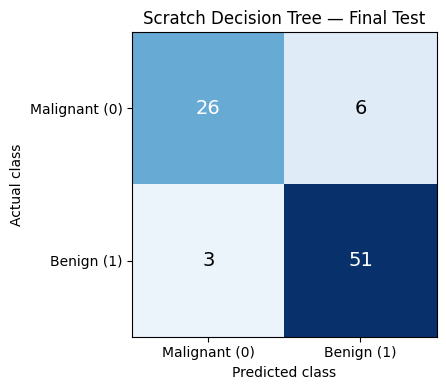

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict using the fitted scratch tree and unscaled test features.
y_test_pred_dt_scratch = dt_scratch.predict(X_test)

malignant_column = np.flatnonzero(dt_scratch.classes_ == 0).item()
p_test_malignant_dt_scratch = dt_scratch.predict_proba(
    X_test
)[:, malignant_column]

# Calculate metrics using our NumPy implementation.
test_scores_dt_scratch, cm_test_dt_scratch = evaluate_binary_scratch(
    y_test,
    y_test_pred_dt_scratch,
    p_test_malignant_dt_scratch
)

test_metrics_dt_scratch = pd.DataFrame({
    "Metric": list(test_scores_dt_scratch.keys()),
    "Test score": list(test_scores_dt_scratch.values())
})

print("Test samples:", len(y_test))
print("Maximum depth:", dt_scratch.max_depth)
print("Minimum samples per leaf:", dt_scratch.min_samples_leaf)
display(test_metrics_dt_scratch.round(4))

# Matrix order: [[TP, FN], [FP, TN]].
tp, fn, fp, tn = cm_test_dt_scratch.ravel()
print("True positives:", tp)
print("False negatives:", fn)
print("False positives:", fp)
print("True negatives:", tn)

# Plot without sklearn.
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_test_dt_scratch, cmap="Blues", vmin=0)

labels = ["Malignant (0)", "Benign (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")
ax.set_title("Scratch Decision Tree — Final Test")

for row in range(2):
    for column in range(2):
        value = cm_test_dt_scratch[row, column]
        color = "white" if value > cm_test_dt_scratch.max() / 2 else "black"
        ax.text(
            column, row, str(value),
            ha="center", va="center", color=color, fontsize=14
        )

plt.tight_layout()
plt.show()

### Interpretation — Scratch Decision Tree Test Results

The scratch tree correctly classified **77 of 86 test samples**:
- **26 true positives**, **6 false negatives**
- **3 false positives**, **51 true negatives**

Accuracy was **89.53%**, malignant precision **89.66%**, recall **81.25%**,
F1 **85.25%**, and ROC-AUC **0.9034**.

The confusion-matrix counts and label-based metrics match the library
tree. ROC-AUC differs slightly (**0.9034 versus 0.9010**), indicating
a difference in probability ranking despite matching aggregate counts.

Both Logistic Regression implementations achieved higher test scores
on every reported metric and missed fewer malignant samples (**2 versus 6**).

These findings apply to this test split. No model settings were changed
using the test results.

### 36. Final Comparison — All Four Implementations

We compare all four implementations on the same 86 test samples.
Malignant (label 0) is the positive class.

The table includes all five numerical scores and the four confusion-matrix
counts. Plots compare the scores and the numbers of false positives and
false negatives.

We reuse the stored test results. No models are retrained or tuned.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the full-precision results and confusion matrices already calculated.
stored_results = [
    ("Logistic Regression — Library", test_metrics_lr, cm_test_lr),
    ("Logistic Regression — Scratch",
     test_metrics_lr_scratch, cm_test_lr_scratch),
    ("Decision Tree — Library", test_metrics_dt, cm_test_dt),
    ("Decision Tree — Scratch",
     test_metrics_dt_scratch, cm_test_dt_scratch)
]

metric_names = {
    "Accuracy": "Accuracy",
    "Precision — malignant": "Precision",
    "Recall — malignant": "Recall",
    "F1 — malignant": "F1",
    "ROC-AUC — malignant": "ROC-AUC"
}

comparison_rows = []

for model_name, metric_table, matrix in stored_results:
    scores = metric_table.set_index("Metric")["Test score"]

    # Our matrices use malignant-first ordering: [[TP, FN], [FP, TN]].
    tp, fn, fp, tn = np.asarray(matrix).ravel()
    assert tp + fn + fp + tn == len(y_test)

    row = {"Implementation": model_name}
    row.update({
        short_name: float(scores[original_name])
        for original_name, short_name in metric_names.items()
    })
    row.update({
        "TP": int(tp),
        "FN": int(fn),
        "FP": int(fp),
        "TN": int(tn)
    })
    comparison_rows.append(row)

final_comparison = pd.DataFrame(
    comparison_rows
).set_index("Implementation")

print("Final test comparison — malignant is the positive class")
print("Scores are on a 0–1 scale; confusion-matrix values are counts.")
display(final_comparison.round(4))

Final test comparison — malignant is the positive class
Scores are on a 0–1 scale; confusion-matrix values are counts.


,Accuracy,Precision,Recall,F1,ROC-AUC,TP,FN,FP,TN
Implementation,,,,,,,,,
Logistic Regression — Library,0.9767,1.0000,0.9375,0.9677,0.9936,30,2,0,54
Logistic Regression — Scratch,0.9767,1.0000,0.9375,0.9677,0.9936,30,2,0,54
Decision Tree — Library,0.8953,0.8966,0.8125,0.8525,0.9010,26,6,3,51
Decision Tree — Scratch,0.8953,0.8966,0.8125,0.8525,0.9034,26,6,3,51


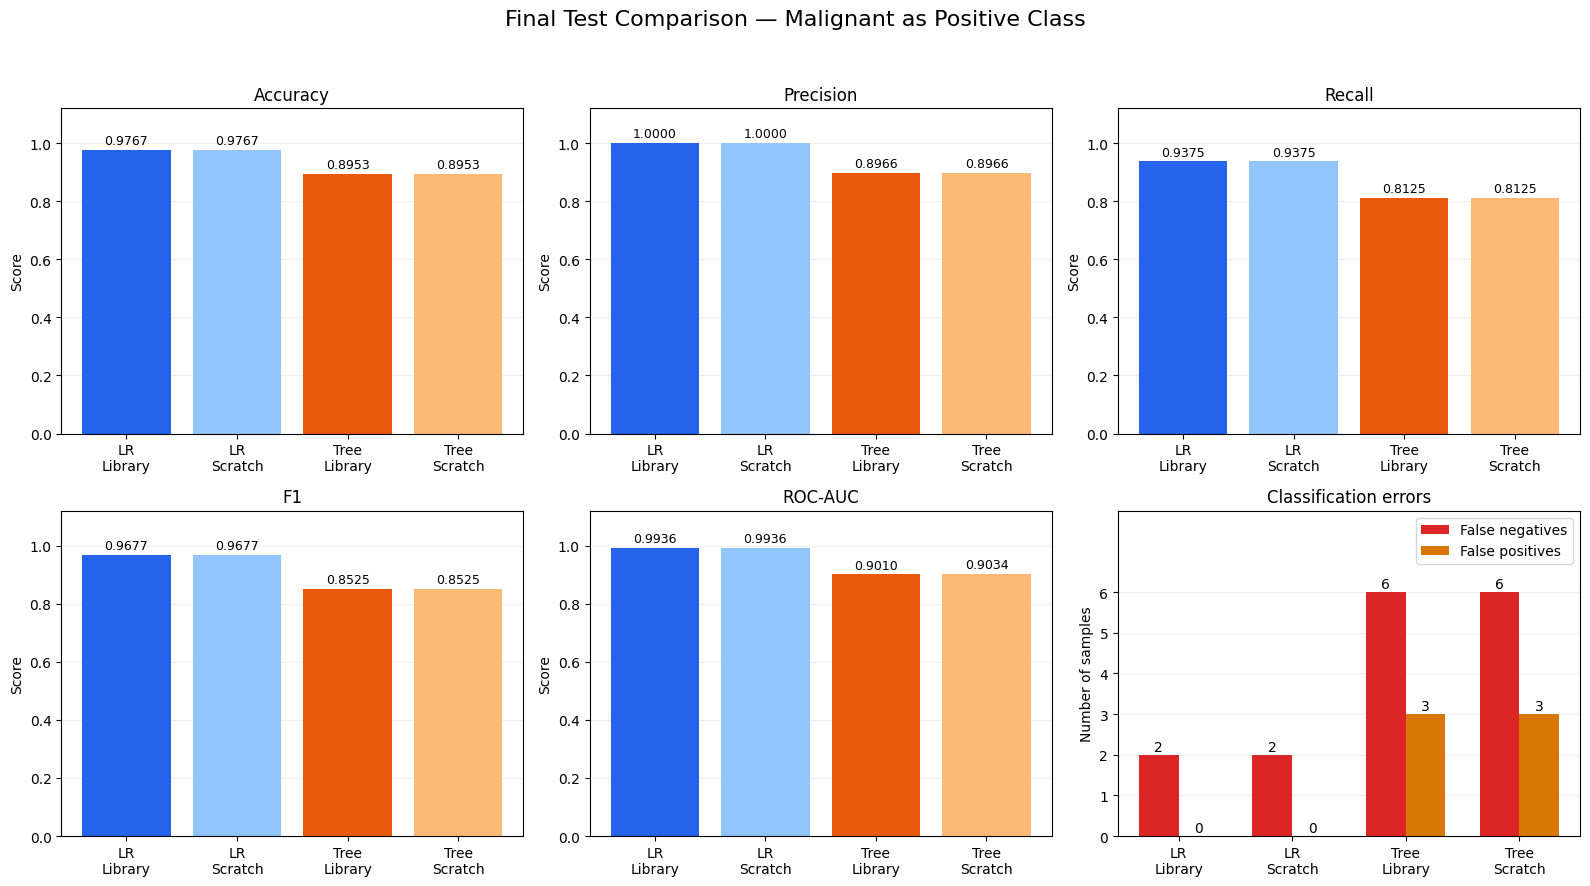

In [41]:
short_labels = [
    "LR\nLibrary", "LR\nScratch",
    "Tree\nLibrary", "Tree\nScratch"
]
colors = ["#2563EB", "#93C5FD", "#EA580C", "#FDBA74"]
x = np.arange(len(final_comparison))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Five score plots, each with the same scale.
for ax, metric in zip(
    axes.flat[:5],
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
):
    values = final_comparison[metric].to_numpy()
    bars = ax.bar(x, values, color=colors)

    ax.set_xticks(x)
    ax.set_xticklabels(short_labels)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylabel("Score")
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.4f}",
            ha="center",
            fontsize=9
        )

# Sixth plot: distinguish the two types of errors.
ax = axes[1, 2]
width = 0.35

fn_bars = ax.bar(
    x - width / 2, final_comparison["FN"],
    width, label="False negatives", color="#DC2626"
)
fp_bars = ax.bar(
    x + width / 2, final_comparison["FP"],
    width, label="False positives", color="#D97706"
)

ax.set_xticks(x)
ax.set_xticklabels(short_labels)
ax.set_ylabel("Number of samples")
ax.set_title("Classification errors")

largest_error_count = int(final_comparison[["FN", "FP"]].to_numpy().max())
ax.set_ylim(0, largest_error_count + 2)
ax.set_yticks(range(largest_error_count + 1))
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

for bars in [fn_bars, fp_bars]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(int(bar.get_height())),
            ha="center"
        )

fig.suptitle(
    "Final Test Comparison — Malignant as Positive Class",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

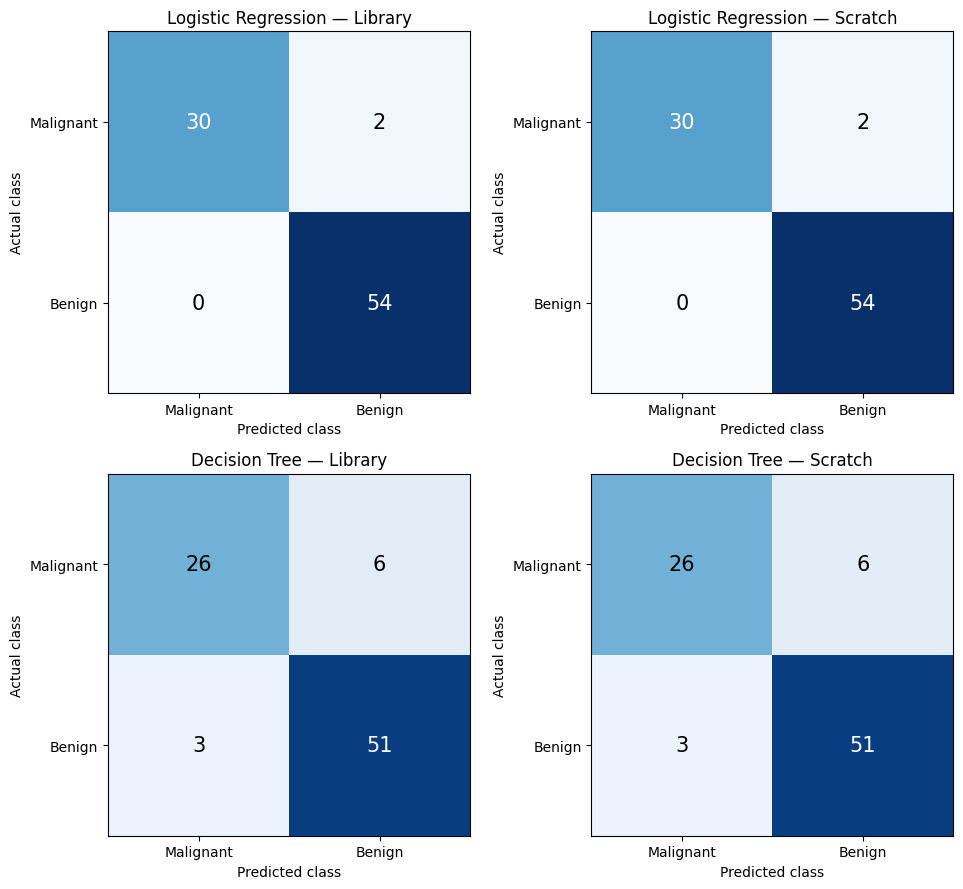

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
class_labels = ["Malignant", "Benign"]

# Shared color scale makes the matrices directly comparable.
max_count = max(
    np.asarray(matrix).max()
    for _, _, matrix in stored_results
)

for ax, (model_name, _, matrix) in zip(axes.flat, stored_results):
    matrix = np.asarray(matrix)
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=max_count)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title(model_name)

    for row in range(2):
        for column in range(2):
            value = matrix[row, column]
            ax.text(
                column, row, str(value),
                ha="center", va="center", fontsize=15,
                color="white" if value > max_count / 2 else "black"
            )

plt.tight_layout()
plt.show()

### 37. Overall Conclusion and Limitations

#### Conclusion

We implemented Logistic Regression and Decision Tree using scikit-learn and from scratch on the Breast Cancer Wisconsin dataset. We used a stratified 70% training, 15% validation, and 15% testing split. Scaling parameters were calculated from training data, and hyperparameters were selected using validation results.

Logistic Regression performed best on the 86 test samples. Both implementations achieved 97.67% accuracy, 93.75% malignant recall, 0.9677 F1, and 0.9936 ROC-AUC. Each missed 2 malignant samples and produced no false positives.

Both Decision Trees achieved 89.53% accuracy, 81.25% malignant recall, and 0.8525 F1. Each missed 6 malignant samples and produced 3 false positives. Their ROC-AUC scores differed slightly because the learned splits produced different probability rankings.

The scratch Logistic Regression closely reproduced the library model. The scratch Decision Tree matched the library tree’s aggregate classification results despite differences in some internal splits and probability estimates.

#### Limitations

- Results come from one dataset and one test split of 86 samples; performance may change with another split or population.
- Hyperparameter selection used a single validation set and a limited search grid.
- Matching aggregate metrics does not prove that two implementations are identical.
- Strong test performance does not establish clinical suitability. Logistic Regression still missed 2 of the 32 malignant test samples.
- Test results were used only for final reporting, without further model tuning.